# Bibliotecas

In [2]:
import pandas               as pd
import numpy                as np
import matplotlib.pyplot    as plt
import seaborn              as sns
import statsmodels.api      as sm
import networkx             as nx
import math
import joblib
import json
import shap

from sklearn.model_selection    import train_test_split, RandomizedSearchCV
from sklearn.preprocessing      import RobustScaler, MinMaxScaler
from sklearn.metrics            import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    recall_score,
    precision_score,
    f1_score,
    accuracy_score,
    ConfusionMatrixDisplay,
    precision_recall_curve
    )
from scipy.stats import gaussian_kde
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

# Funções

In [3]:
def plot_curva_roc_auc(y_test, y_probs):
    """
    Plota a Curva ROC e calcula o AUC (Area Under the Curve) para avaliar o desempenho do modelo de classificação.
    """
    auc = roc_auc_score(y_test, y_probs)
    print(f"ROC AUC Score: {auc:.2f}")

    # Plotando a Curva ROC
    fpr, tpr, thresholds = roc_curve(y_test, y_probs)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='blue', label=f'AUC = {auc:.2f}')
    plt.plot([0, 1], [0, 1], color='red', linestyle='--')
    plt.xlabel('Taxa de Falso Positivo (1 - Especificidade)')
    plt.ylabel('Taxa de Verdadeiro Positivo (Sensibilidade/Recall)')
    plt.title(f'Curva ROC')
    plt.legend()
    plt.show()

In [4]:
def analise_cutoff(y_test, y_pred_proba, min_cutoff=0.1, max_cutoff=1.01, passo=0.05):
    """
    Analisa o desempenho do modelo em diferentes valores de cutoff (limiar de decisão) para classificação binária.
    Gera um gráfico mostrando as métricas de desempenho (accuracy, f1_score, precision, recall, roc_auc) em função do cutoff.
    """
    cutoffs = np.arange(min_cutoff, max_cutoff, passo)

    # Garantir que y_pred_proba seja um array unidimensional para o DataFrame
    y_pred_proba = np.array(y_pred_proba).flatten()
    df = pd.DataFrame(np.round(y_pred_proba, 2), columns=['prob_churn'])

    metricas_por_cutoff_reglog = []
    for c in cutoffs:
        y_pred_cutoff = (df['prob_churn'] >= c).astype(int)
        acc = accuracy_score(y_test, y_pred_cutoff)
        f1 = f1_score(y_test, y_pred_cutoff)
        precision = precision_score(y_test, y_pred_cutoff, zero_division=0)
        roc_auc = roc_auc_score(y_test, y_pred_cutoff)
        recall = recall_score(y_test, y_pred_cutoff)

        metricas_por_cutoff_reglog.append({
            'cutoff': c,
            'accuracy': acc,
            'f1_score': f1,
            'precision': precision,
            'recall': recall,
            'roc_auc': roc_auc
        })

    df_metricas_por_cutoff_reglog = pd.DataFrame(metricas_por_cutoff_reglog)

    plt.figure(figsize=(10, 6))
    for col in df_metricas_por_cutoff_reglog.columns[1:]:
        plt.plot(df_metricas_por_cutoff_reglog['cutoff'], df_metricas_por_cutoff_reglog[col], label=col)

    plt.xlabel('Cutoff')
    plt.ylabel('Metrica')
    plt.xticks(np.arange(min_cutoff, max_cutoff + 0.01, step=passo))
    plt.title('Metricas por Cutoff')
    plt.legend()
    plt.grid(True)
    plt.show()

In [5]:
def plot_precision_recall_curve(y_test, y_probs):
    """
    Plota a Curva Precision-Recall para avaliar o desempenho do modelo de classificação.
    """
    precision, recall, thresholds = precision_recall_curve(y_test, y_probs)
    df_precision_recall = pd.DataFrame({
        'Precision':    precision,
        'Recall':       recall,
        'Threshold':    np.append(thresholds, 1.0)
    })

    f1 = 2 * (df_precision_recall['Precision'] * df_precision_recall['Recall']) / (
        df_precision_recall['Precision'] + df_precision_recall['Recall']
    )

    best_idx = np.argmax(f1)
    best_threshold = df_precision_recall['Threshold'].iloc[best_idx]

    plt.figure(figsize=(10,6))
    plt.grid()

    plt.plot(df_precision_recall['Threshold'], df_precision_recall['Precision'], label='Precision')
    plt.plot(df_precision_recall['Threshold'], df_precision_recall['Recall'], label='Recall')
    plt.plot(df_precision_recall['Threshold'], f1, label='F1 Score', color='green')

    plt.axvline(best_threshold, color='red', linestyle='--', label=f'Best Threshold: {best_threshold:.2f}')

    plt.legend()
    plt.grid()
    plt.xlabel('Threshold')
    plt.ylabel('Score')
    plt.title(f'Precision/Recall vs Threshold com ótimo F1 - Threshold ótimo: {best_threshold:.2f}')

    plt.show()

    return best_threshold

In [6]:
def network_corr(data, corr, corr_interval=[-0.75, 0.75]):
    """
    Plota uma rede de correlação entre as variáveis do DataFrame `data` com base na matriz de correlação `corr`.
    Apenas as correlações que estão fora do intervalo definido por `corr_interval` serão exibidas na rede.
    """
    corr = pd.melt(corr.reset_index(), id_vars='index')
    corr.columns = ['x', 'y', 'value']
    high_corr = corr[((corr['value'] <= corr_interval[0]) | (corr['value'] >= corr_interval[1]))]
    high_corr = high_corr[(high_corr['value'] != 1)].reset_index(drop=True)
    sources = list(high_corr.x.unique())
    targets = list(high_corr.y.unique())
    plt.figure(figsize=(10, 10))
    g = nx.from_pandas_edgelist(high_corr, source='x', target='y') 
    layout = nx.spring_layout(g, iterations=50, k=0.6, seed=123)
    target_size = [g.degree(t) * 20 for t in targets]
    nx.draw_networkx_nodes(g, 
                           layout, 
                           nodelist=targets, 
                           node_size=target_size)
    # Draw every connection
    nx.draw_networkx_nodes(g, layout, nodelist=sources, node_size=400, alpha=0.5)

    nx.draw_networkx_edges(g, layout, width=1)

    target_dict = dict(zip(targets, targets))
    nx.draw_networkx_labels(g, layout, labels=target_dict)

    plt.axis('off')
    plt.title(f" Rede de Correlação com Intervalo {corr_interval}", fontsize=12)
    plt.show()

# Dataset

In [7]:
dataset = pd.read_csv('dados_brutos\\tarefas_clientes_treino_teste.csv', sep=';')
# Convertendo colunas object com vírgula para float numérico
colunas_para_ajustar = list(dataset.filter(regex='perc').columns) + \
                        list(dataset.filter(regex='score').columns) + \
                        list(dataset.filter(regex='valor').columns) + \
                        list(dataset.filter(regex='media').columns)

for col in colunas_para_ajustar:
    dataset[col] = dataset[col].astype(str).str.replace(',', '.').astype(float)

dataset.head()

,cod_cliente,valor_medio_contrato,meses_vida_cliente,qt_tarefas_total,media_dias_exec,qt_tarefas_sd,media_dias_exec_tarefa_sd,perc_qt_tarefas_sd,qt_tarefas_hd,media_dias_exec_tarefa_hd,...,perc_qt_tarefas_bug,qt_categorias_distintas,qt_subcategorias_distintas,qt_grupos_envolvidos,perc_qt_prioridade_normal,perc_qt_prioridade_parcial,perc_qt_prioridade_urgente,perc_qt_prioridade_maxima,perc_qt_prioridade_reforco,churn
0,43637,1037.88,26,476,0.0840,0,0.0,0.0,0,0.0000,...,0.0,3,6,3,100.00000,0.00000,0.0,0.0,0.0,1
1,45284,0.00,37,15,0.2667,0,0.0,0.0,11,0.3636,...,0.0,4,7,4,80.00000,0.00000,20.0,0.0,0.0,0
2,45852,468.06,20,3,0.3333,0,0.0,0.0,0,0.0000,...,0.0,3,3,1,66.66667,33.33333,0.0,0.0,0.0,0
3,46365,300.00,0,3,0.3333,0,0.0,0.0,0,0.0000,...,0.0,3,3,1,100.00000,0.00000,0.0,0.0,0.0,1
4,46396,332.01,12,3,0.3333,0,0.0,0.0,0,0.0000,...,0.0,3,3,0,100.00000,0.00000,0.0,0.0,0.0,0


In [8]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4068 entries, 0 to 4067
Data columns (total 29 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cod_cliente                 4068 non-null   int64  
 1   valor_medio_contrato        4068 non-null   float64
 2   meses_vida_cliente          4068 non-null   int64  
 3   qt_tarefas_total            4068 non-null   int64  
 4   media_dias_exec             4068 non-null   float64
 5   qt_tarefas_sd               4068 non-null   int64  
 6   media_dias_exec_tarefa_sd   4068 non-null   float64
 7   perc_qt_tarefas_sd          4068 non-null   float64
 8   qt_tarefas_hd               4068 non-null   int64  
 9   media_dias_exec_tarefa_hd   4068 non-null   float64
 10  perc_qt_tarefas_hd          4068 non-null   float64
 11  qt_tarefas_reclamacao       4068 non-null   int64  
 12  media_dias_exec_reclamacao  4068 non-null   float64
 13  perc_qt_tarefas_reclamacao  4068 

In [9]:
# Análise dos valores das colunas de média para churn e não churn
colunas_media = list(dataset.filter(regex='media').columns)

for c in colunas_media:
    mediana_churn = dataset[dataset['churn'] == 1][c].median().round(2)
    mediana_nao_churn = dataset[dataset['churn'] == 0][c].median().round(2)

    media_churn = dataset[dataset['churn'] == 1][c].mean().round(2)
    media_nao_churn = dataset[dataset['churn'] == 0][c].mean().round(2)

    desv_pad_churn = dataset[dataset['churn'] == 1][c].std().round(2)
    desv_pad_nao_churn = dataset[dataset['churn'] == 0][c].std().round(2)

    print(c)
    print(f'Mediana para Churn:             {mediana_churn}')
    print(f'Mediana para Não Churn:         {mediana_nao_churn} \n')
    print(f'Média para Churn:               {media_churn}')
    print(f'Média para Não Churn:           {media_nao_churn} \n')
    print(f'Desvio Padrão para Churn:       {desv_pad_churn}')
    print(f'Desvio Padrão para Não Churn:   {desv_pad_nao_churn} \n')
    print('*' * 30)

media_dias_exec
Mediana para Churn:             15.24
Mediana para Não Churn:         12.95 

Média para Churn:               25.09
Média para Não Churn:           17.34 

Desvio Padrão para Churn:       32.86
Desvio Padrão para Não Churn:   17.63 

******************************
media_dias_exec_tarefa_sd
Mediana para Churn:             0.0
Mediana para Não Churn:         4.22 

Média para Churn:               6.01
Média para Não Churn:           8.39 

Desvio Padrão para Churn:       15.72
Desvio Padrão para Não Churn:   18.03 

******************************
media_dias_exec_tarefa_hd
Mediana para Churn:             5.67
Mediana para Não Churn:         2.46 

Média para Churn:               7.24
Média para Não Churn:           3.65 

Desvio Padrão para Churn:       7.87
Desvio Padrão para Não Churn:   4.39 

******************************
media_dias_exec_reclamacao
Mediana para Churn:             0.0
Mediana para Não Churn:         0.0 

Média para Churn:               1.47
Média para

In [10]:
# Análise dos valores das colunas de quantidade para churn e não churn
colunas_qt = list(dataset.filter(regex='qt').columns)

for c in colunas_qt:
    mediana_churn = dataset[dataset['churn'] == 1][c].median().round(2)
    mediana_nao_churn = dataset[dataset['churn'] == 0][c].median().round(2)

    media_churn = dataset[dataset['churn'] == 1][c].mean().round(2)
    media_nao_churn = dataset[dataset['churn'] == 0][c].mean().round(2)

    desv_pad_churn = dataset[dataset['churn'] == 1][c].std().round(2)
    desv_pad_nao_churn = dataset[dataset['churn'] == 0][c].std().round(2)

    print(c)
    print(f'Mediana para Churn:             {mediana_churn}')
    print(f'Mediana para Não Churn:         {mediana_nao_churn} \n')
    print(f'Média para Churn:               {media_churn}')
    print(f'Média para Não Churn:           {media_nao_churn} \n')
    print(f'Desvio Padrão para Churn:       {desv_pad_churn}')
    print(f'Desvio Padrão para Não Churn:   {desv_pad_nao_churn} \n')
    print('*' * 30)

qt_tarefas_total
Mediana para Churn:             12.0
Mediana para Não Churn:         60.0 

Média para Churn:               29.97
Média para Não Churn:           148.98 

Desvio Padrão para Churn:       64.82
Desvio Padrão para Não Churn:   301.1 

******************************
qt_tarefas_sd
Mediana para Churn:             1.0
Mediana para Não Churn:         3.0 

Média para Churn:               2.51
Média para Não Churn:           12.16 

Desvio Padrão para Churn:       6.71
Desvio Padrão para Não Churn:   38.14 

******************************
perc_qt_tarefas_sd
Mediana para Churn:             3.23
Mediana para Não Churn:         5.07 

Média para Churn:               7.45
Média para Não Churn:           6.05 

Desvio Padrão para Churn:       10.45
Desvio Padrão para Não Churn:   6.35 

******************************
qt_tarefas_hd
Mediana para Churn:             5.0
Mediana para Não Churn:         31.0 

Média para Churn:               13.9
Média para Não Churn:           75.95 

D

qt_categorias_distintas
Mediana para Churn:             6.0
Mediana para Não Churn:         14.0 

Média para Churn:               7.51
Média para Não Churn:           15.48 

Desvio Padrão para Churn:       5.32
Desvio Padrão para Não Churn:   10.96 

******************************
qt_subcategorias_distintas
Mediana para Churn:             6.0
Mediana para Não Churn:         22.0 

Média para Churn:               9.19
Média para Não Churn:           30.16 

Desvio Padrão para Churn:       11.68
Desvio Padrão para Não Churn:   31.64 

******************************
qt_grupos_envolvidos
Mediana para Churn:             5.0
Mediana para Não Churn:         11.0 

Média para Churn:               6.41
Média para Não Churn:           11.46 

Desvio Padrão para Churn:       4.39
Desvio Padrão para Não Churn:   6.95 

******************************
perc_qt_prioridade_normal
Mediana para Churn:             100.0
Mediana para Não Churn:         95.42 

Média para Churn:               95.77
Média 

In [11]:
# Análise dos valores das colunas de quantidade para churn e não churn
colunas_valor = list(dataset.filter(regex='valor').columns)

for c in colunas_valor:
    mediana_churn = dataset[dataset['churn'] == 1][c].median().round(2)
    mediana_nao_churn = dataset[dataset['churn'] == 0][c].median().round(2)

    media_churn = dataset[dataset['churn'] == 1][c].mean().round(2)
    media_nao_churn = dataset[dataset['churn'] == 0][c].mean().round(2)

    desv_pad_churn = dataset[dataset['churn'] == 1][c].std().round(2)
    desv_pad_nao_churn = dataset[dataset['churn'] == 0][c].std().round(2)

    print(c)
    print(f'Mediana para Churn:             {mediana_churn}')
    print(f'Mediana para Não Churn:         {mediana_nao_churn} \n')
    print(f'Média para Churn:               {media_churn}')
    print(f'Média para Não Churn:           {media_nao_churn} \n')
    print(f'Desvio Padrão para Churn:       {desv_pad_churn}')
    print(f'Desvio Padrão para Não Churn:   {desv_pad_nao_churn} \n')
    print('*' * 30)

valor_medio_contrato
Mediana para Churn:             278.76
Mediana para Não Churn:         898.98 

Média para Churn:               608.64
Média para Não Churn:           2306.92 

Desvio Padrão para Churn:       1869.93
Desvio Padrão para Não Churn:   5285.69 

******************************


## Distribuição dos Dados

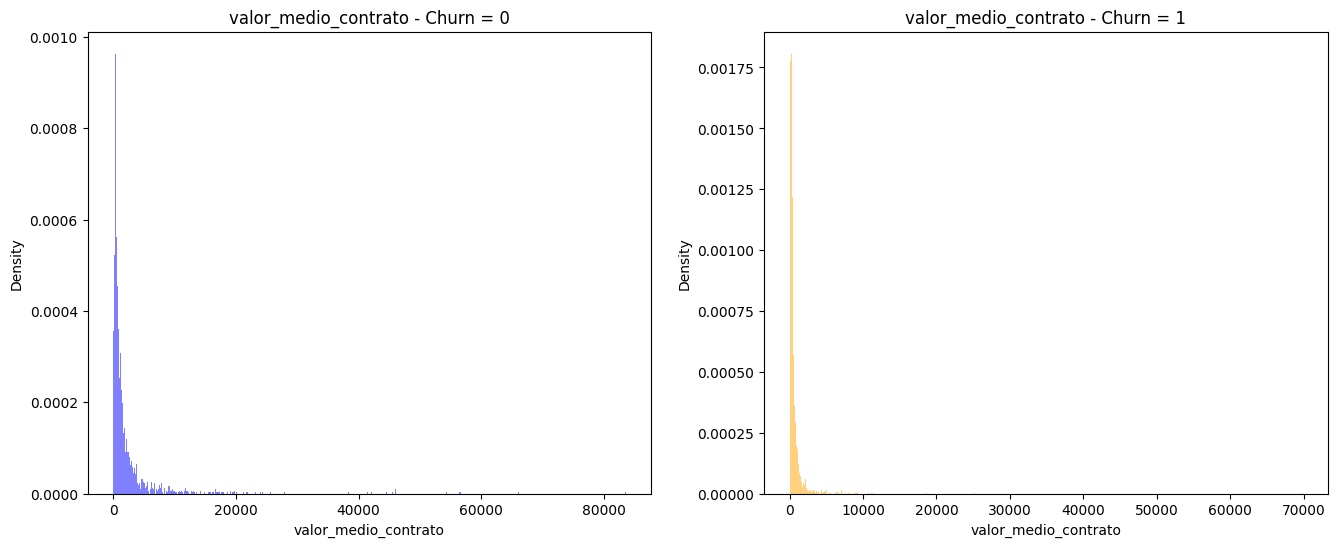

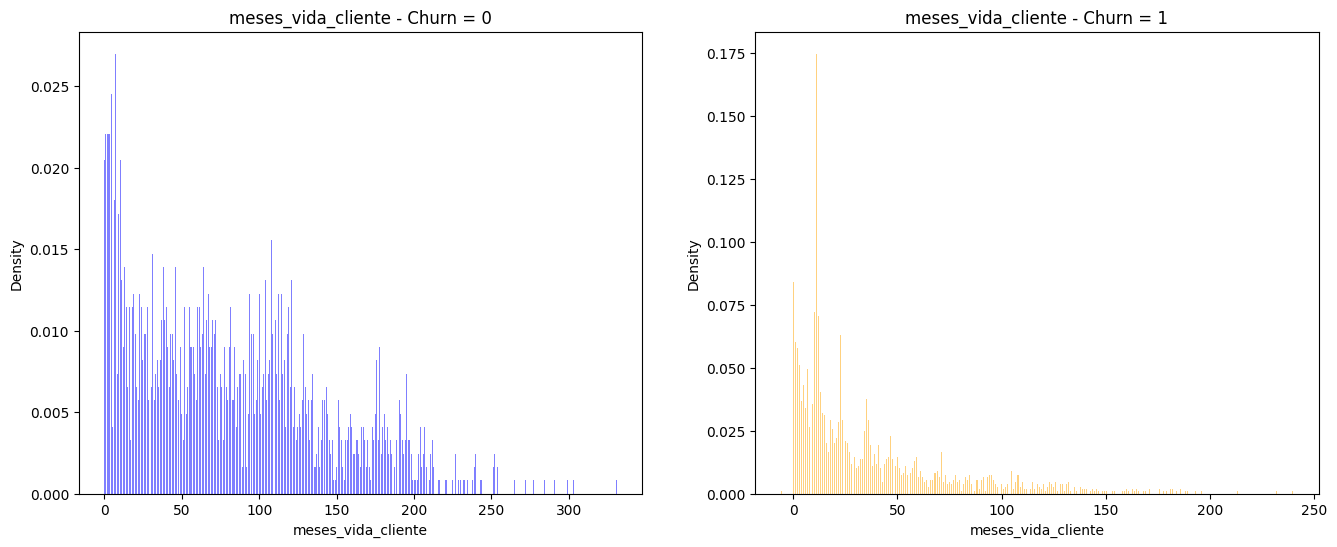

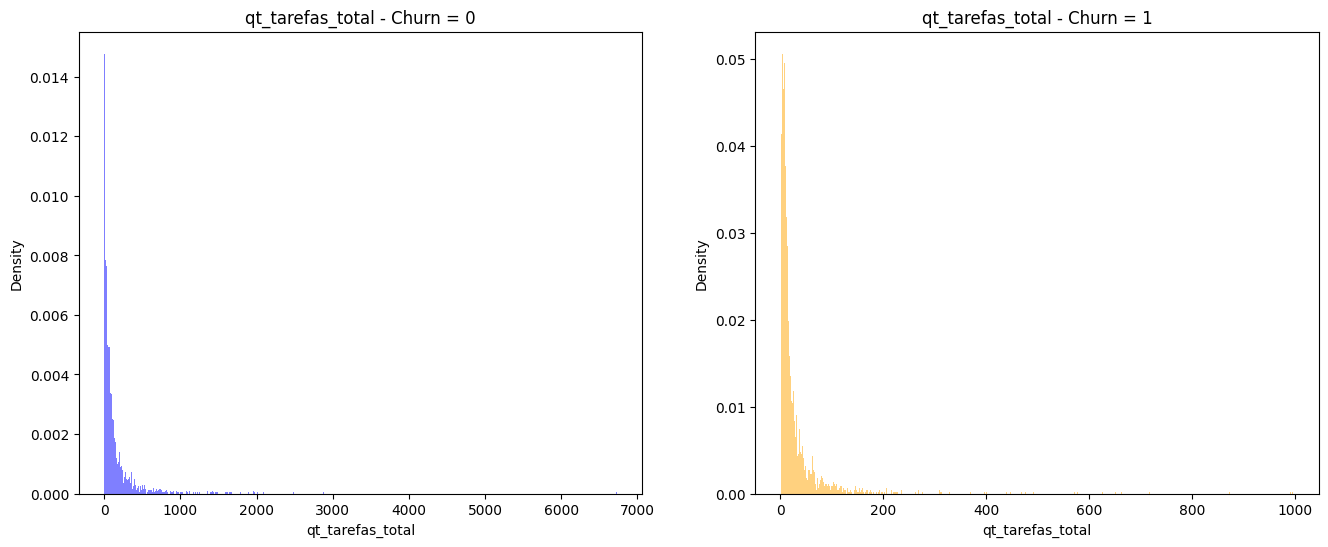

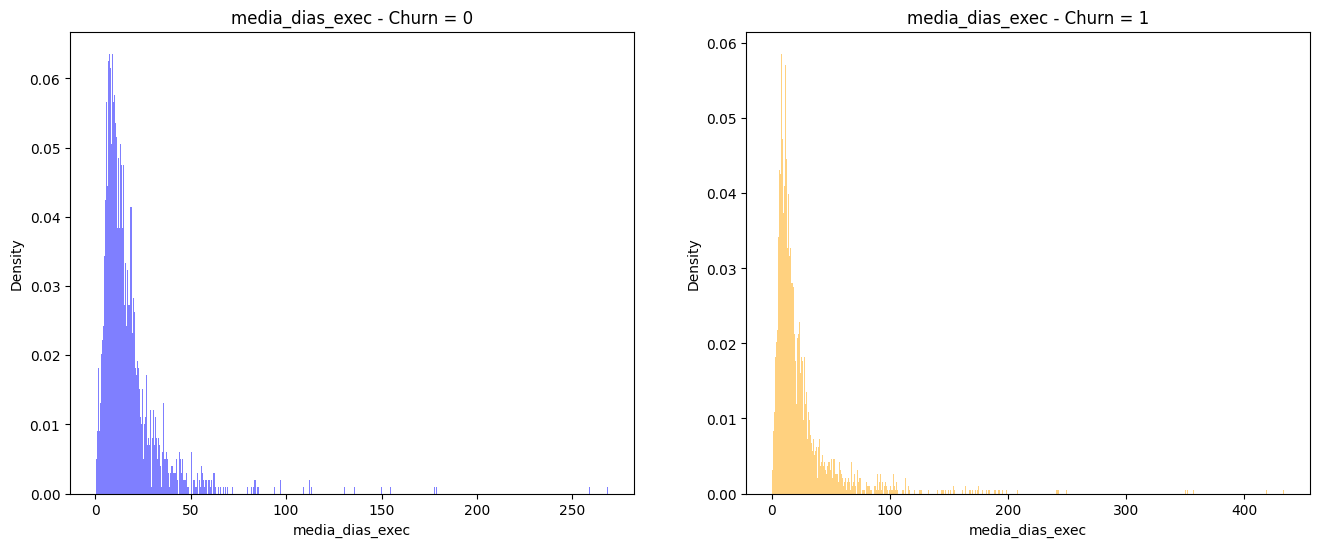

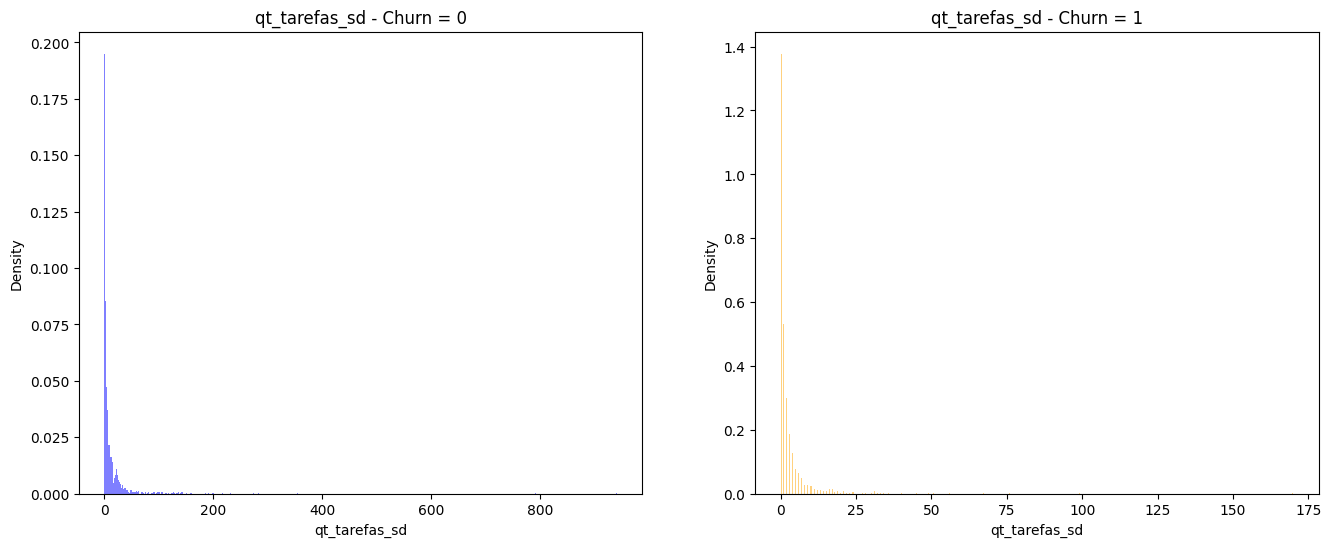

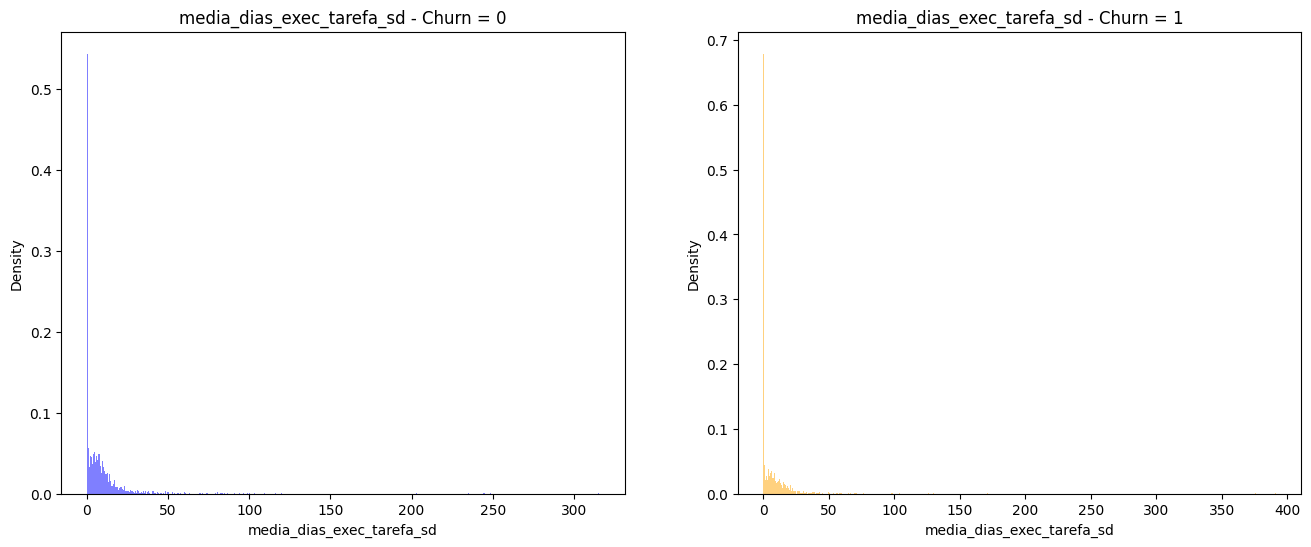

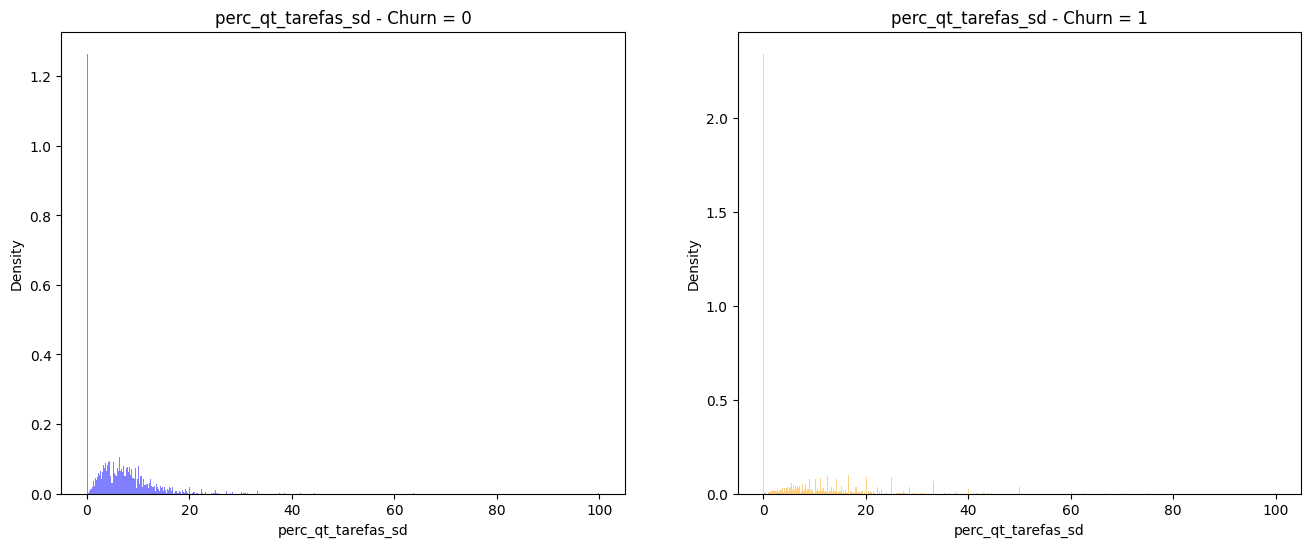

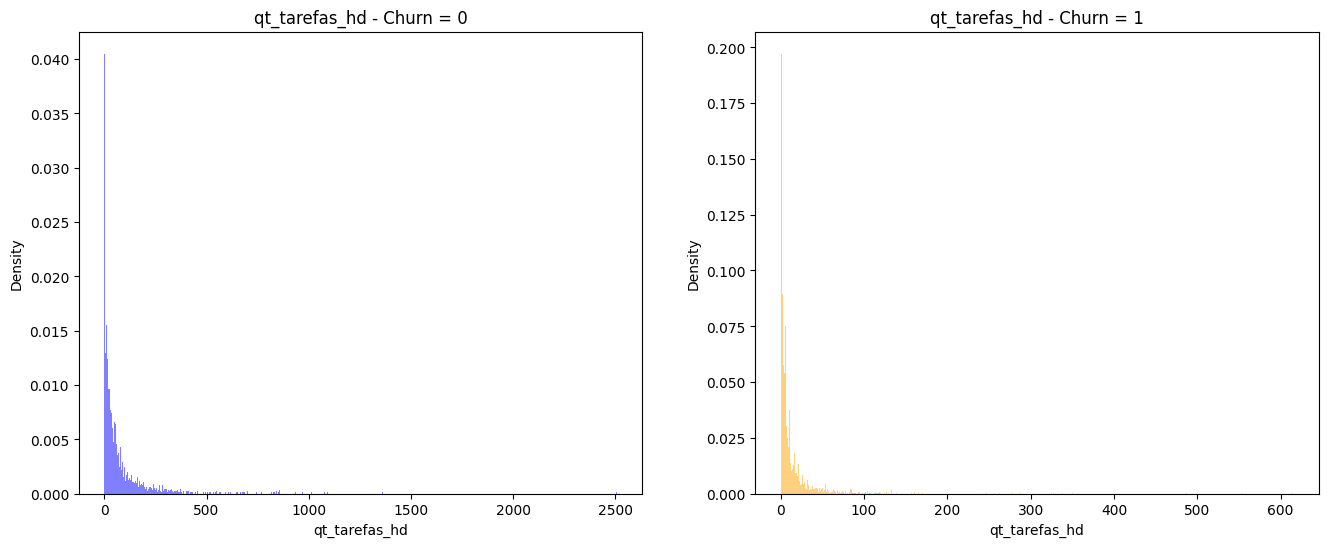

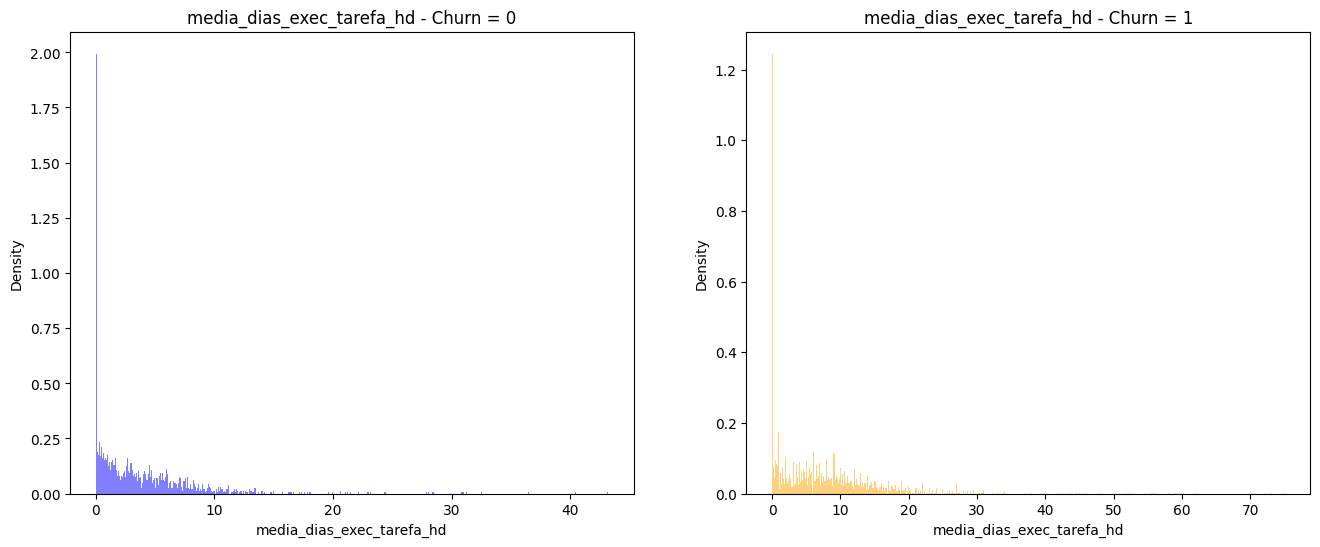

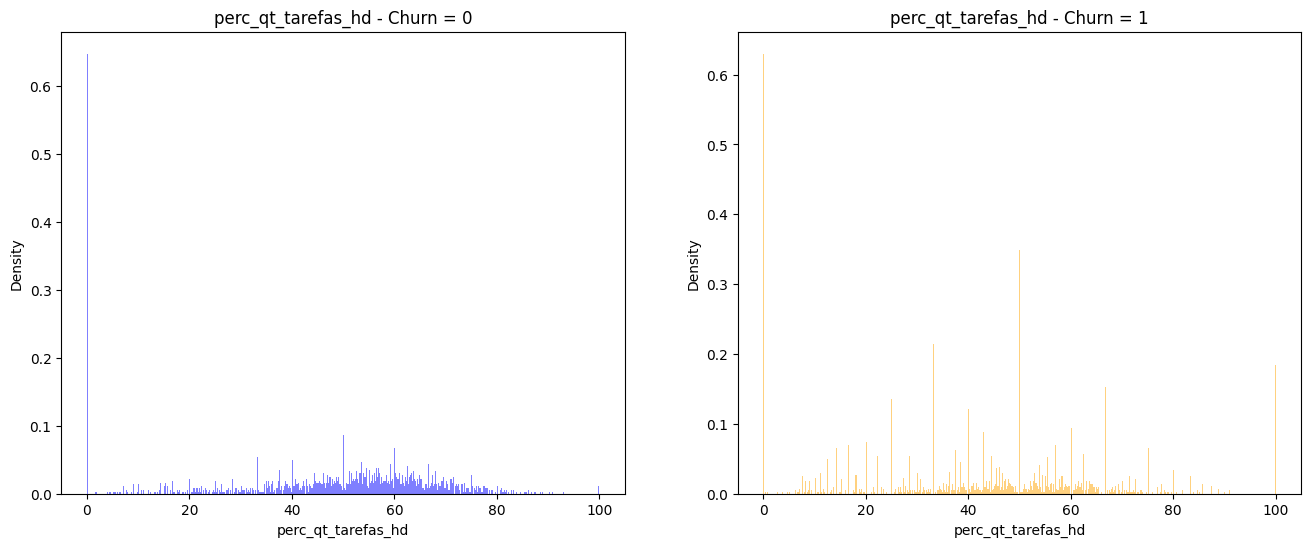

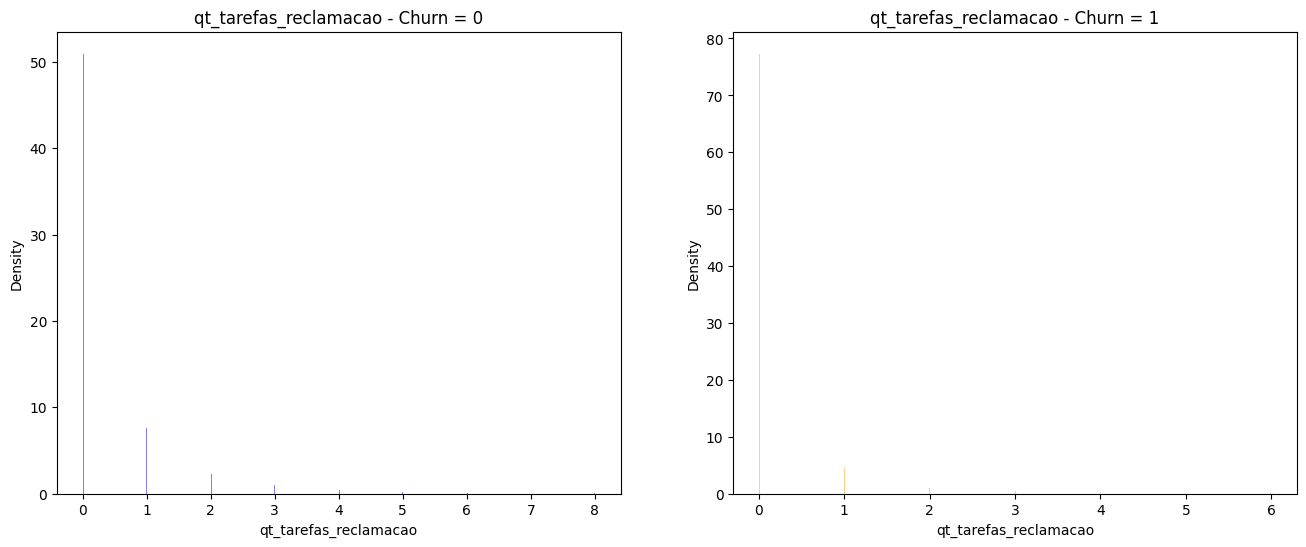

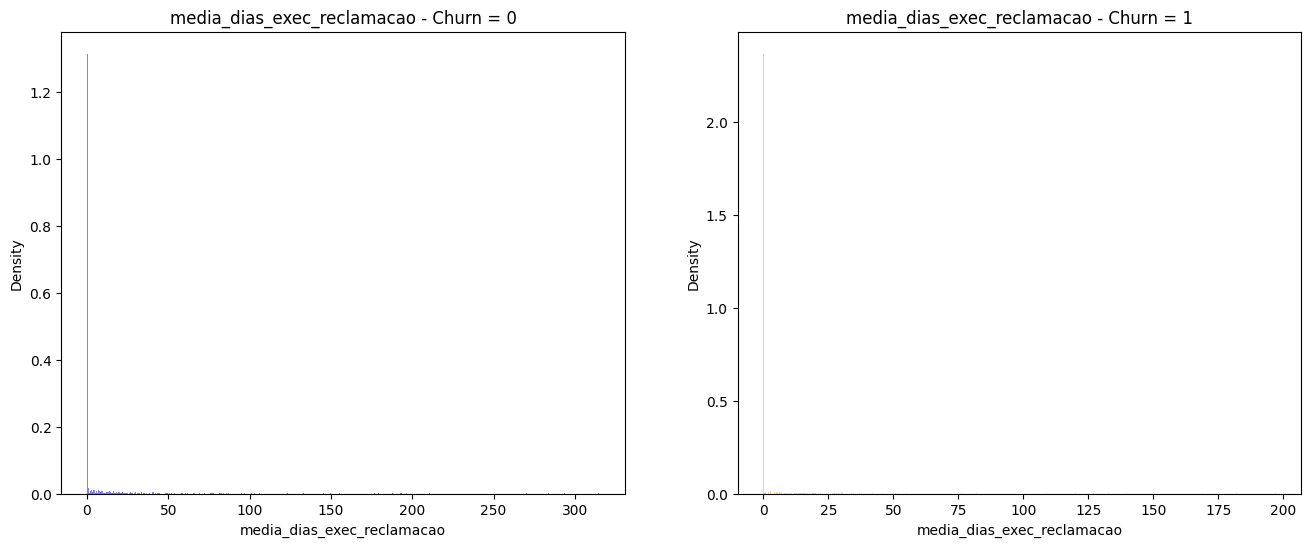

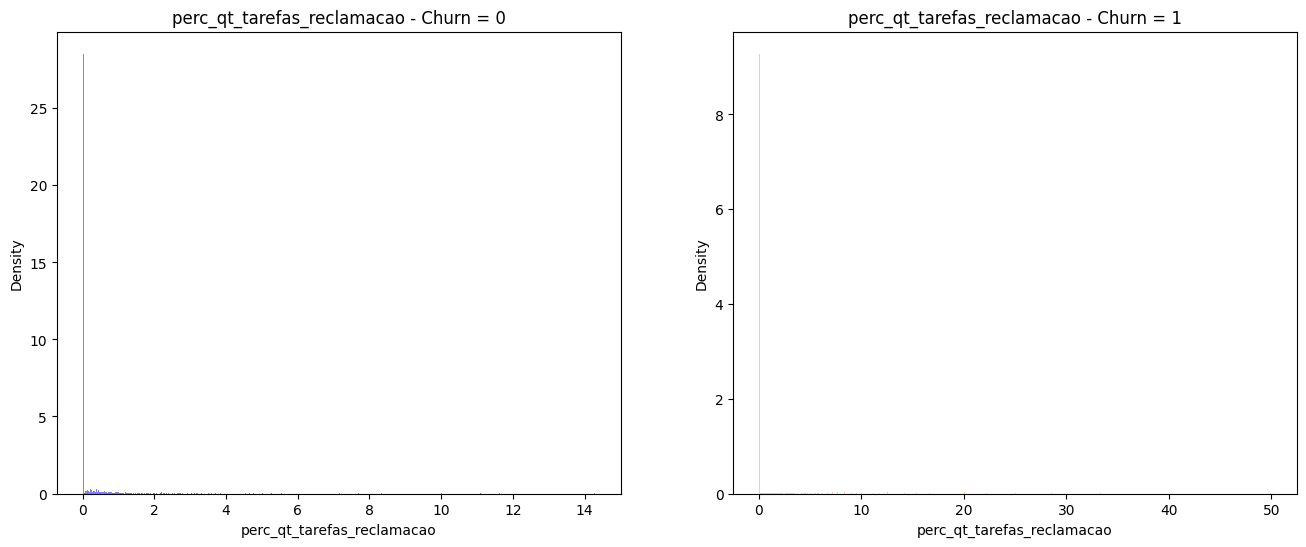

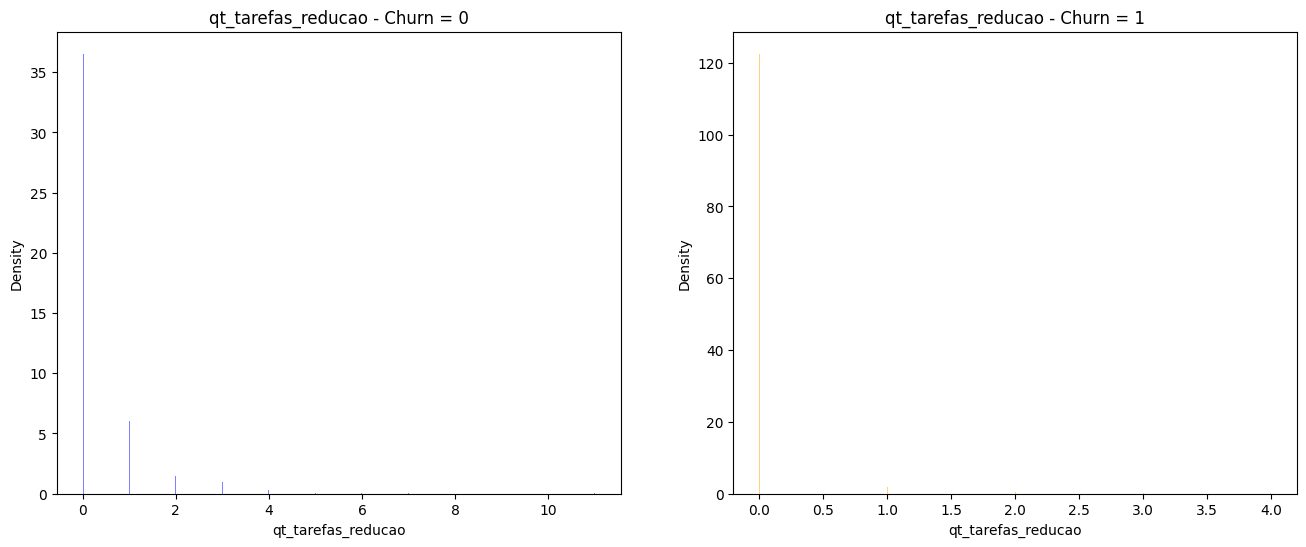

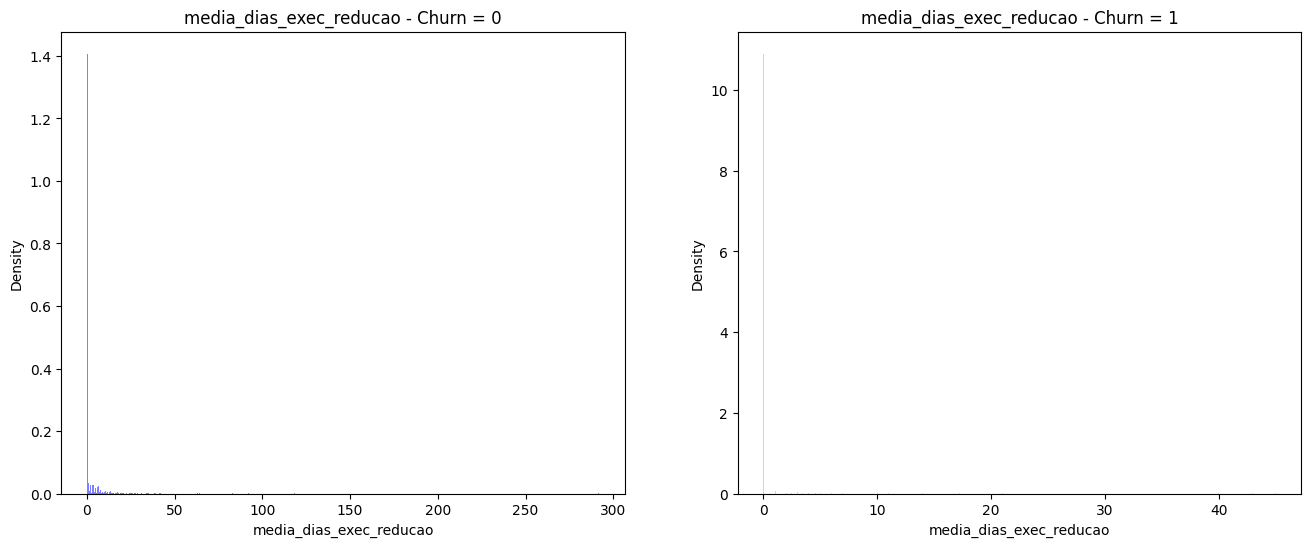

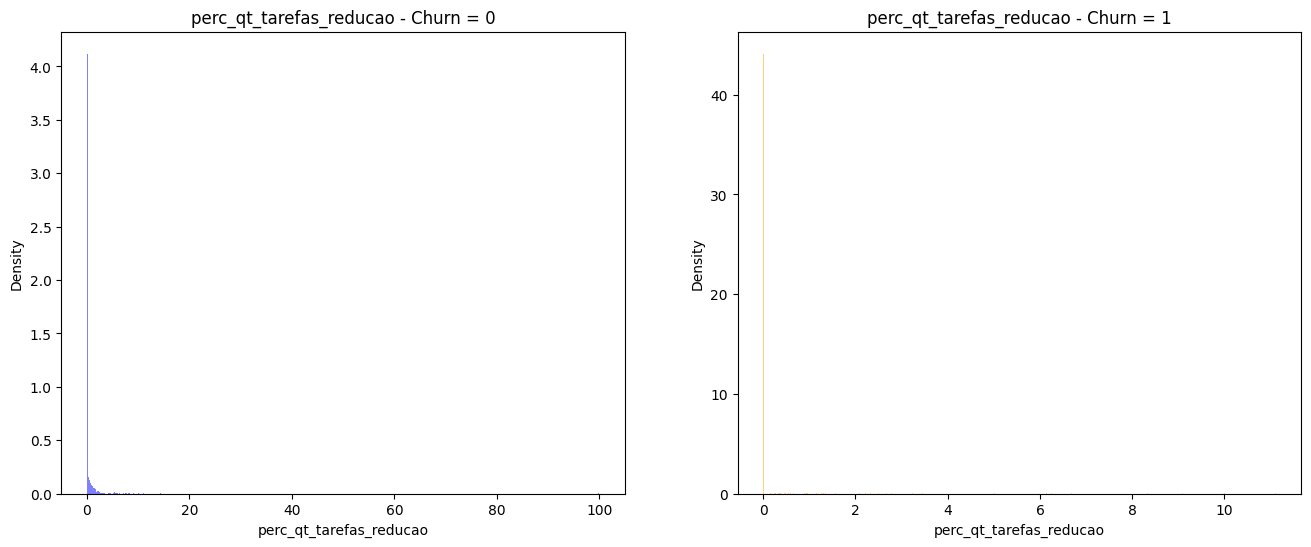

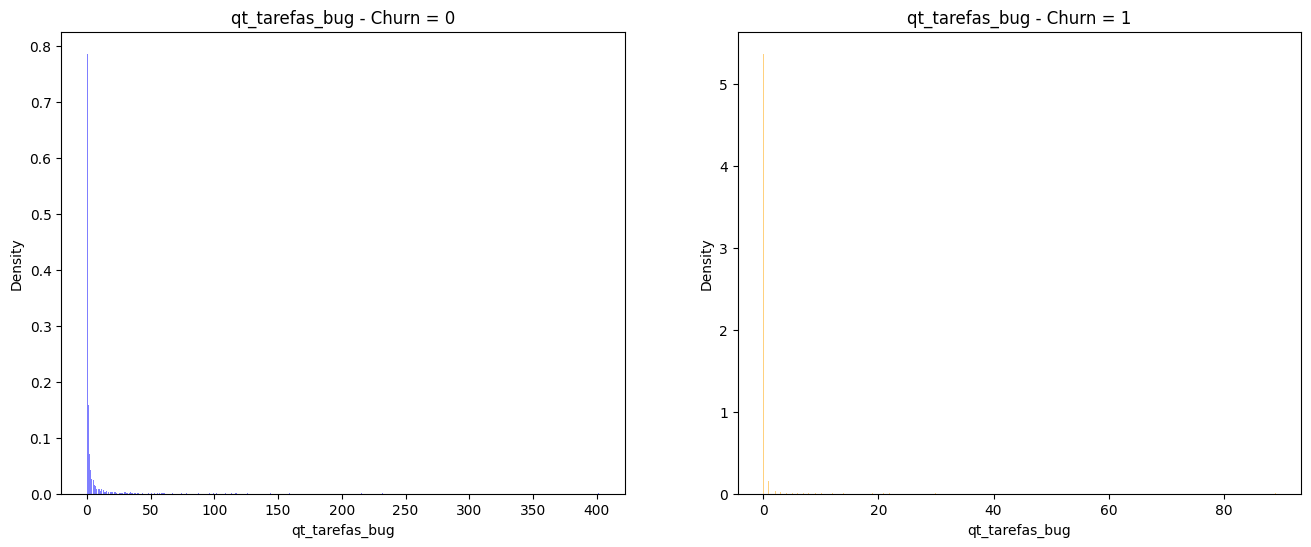

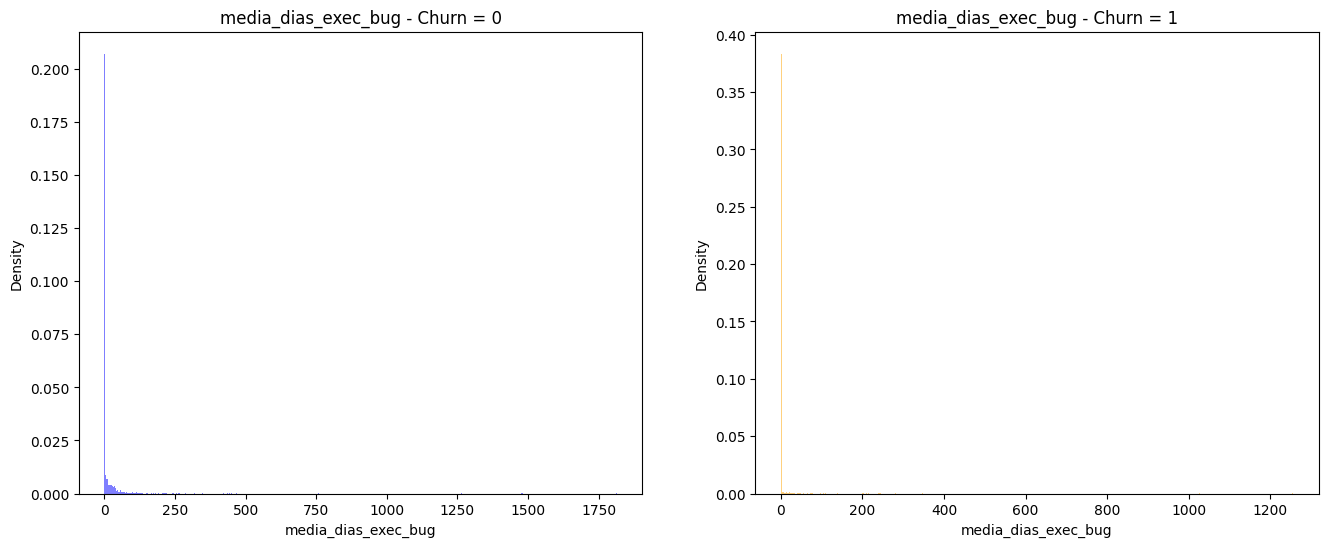

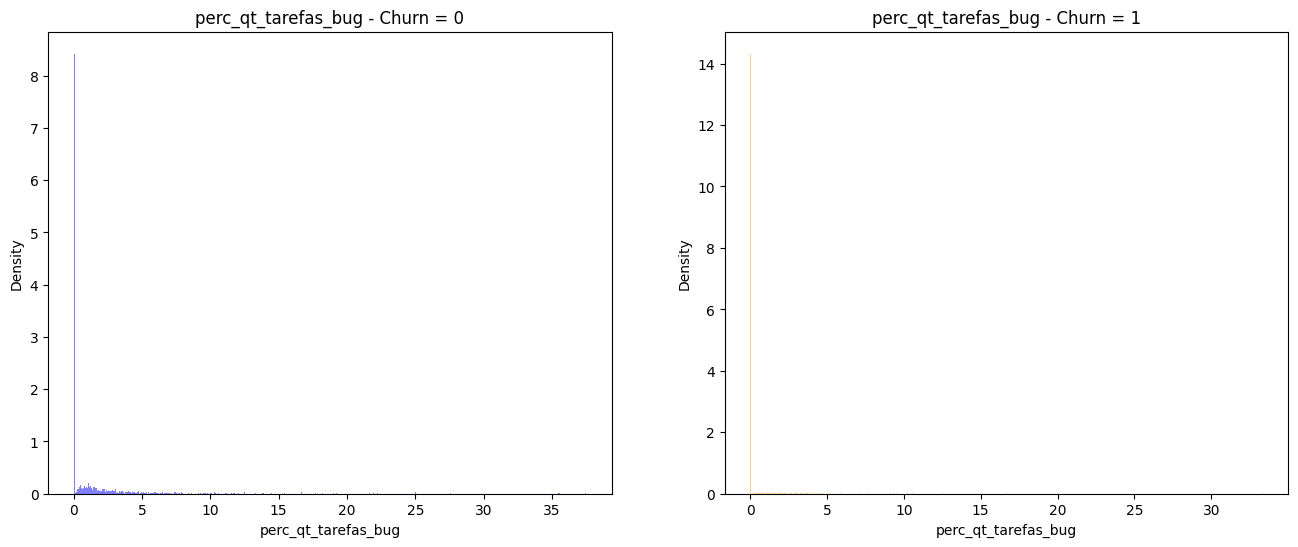

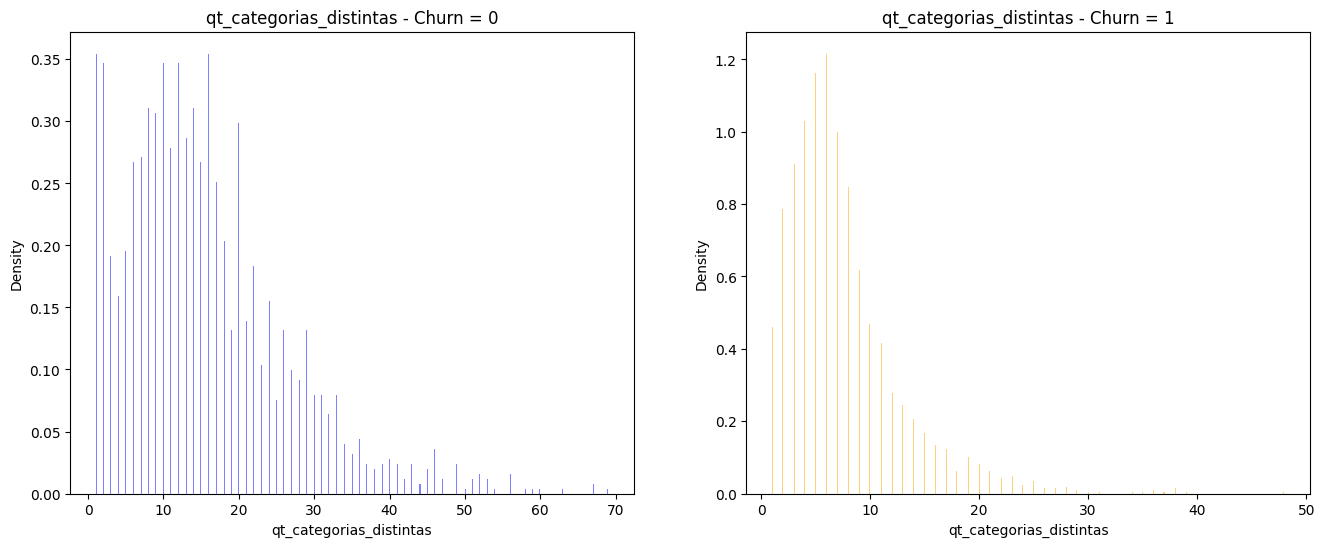

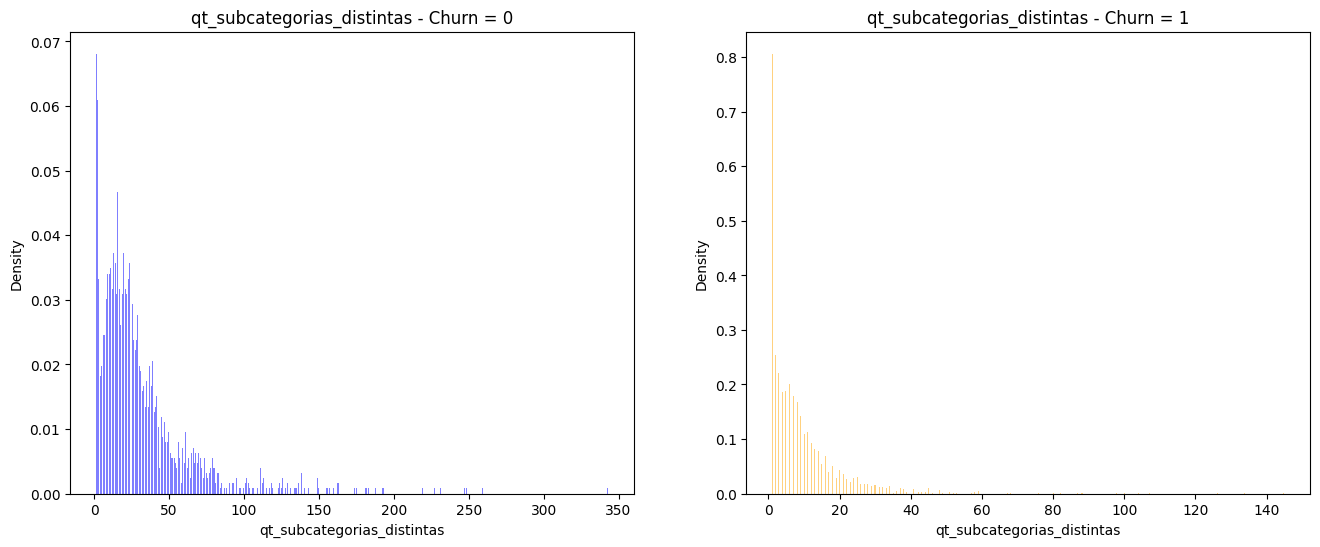

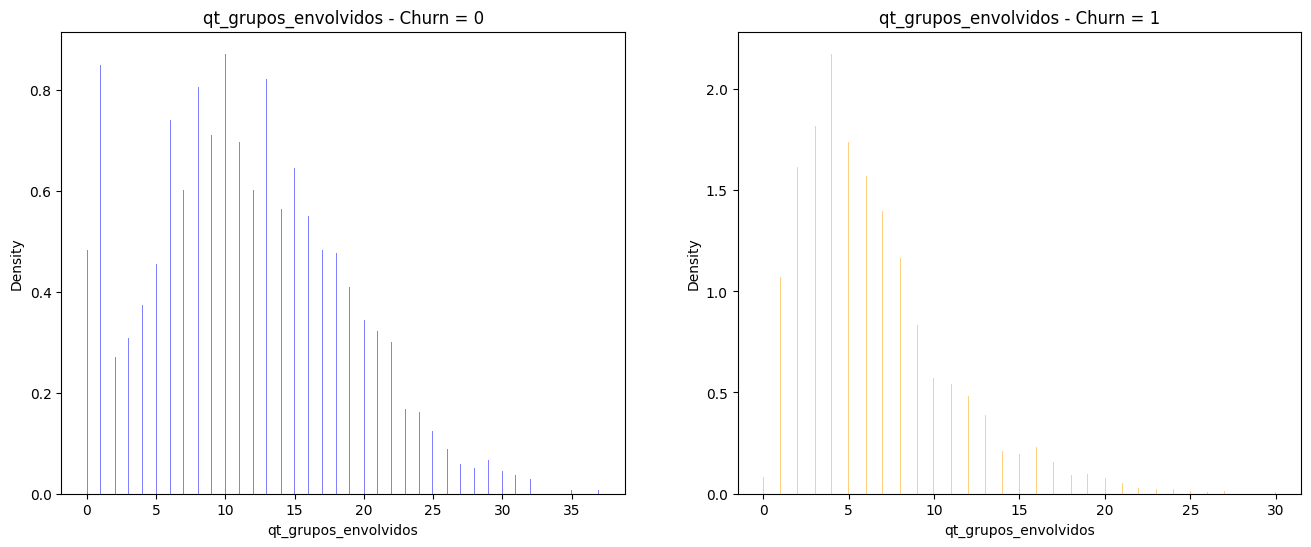

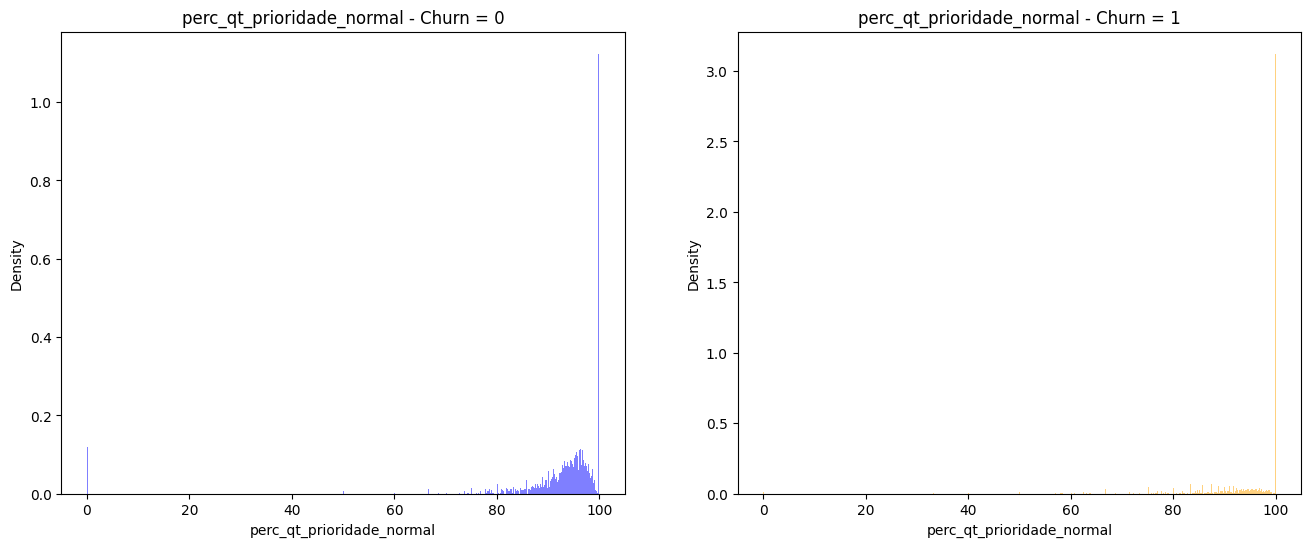

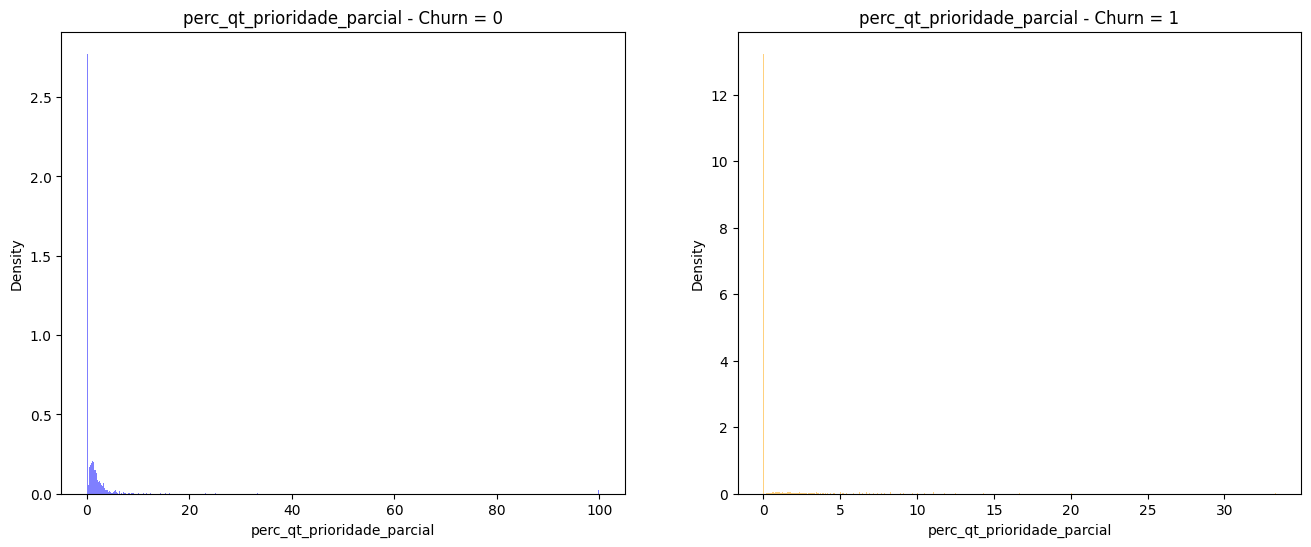

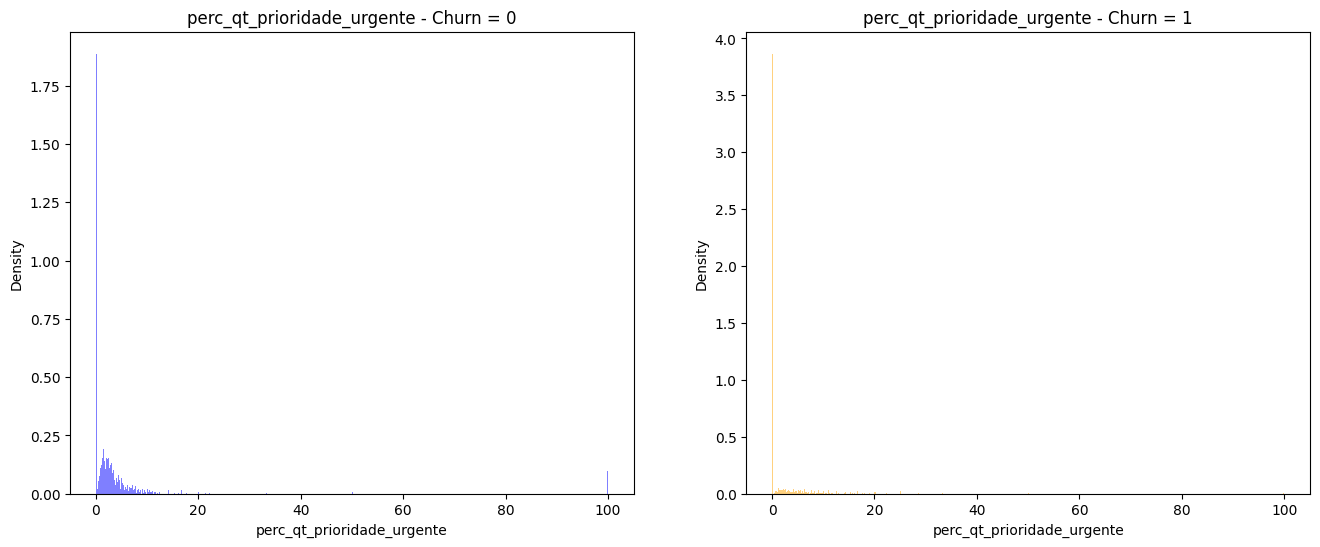

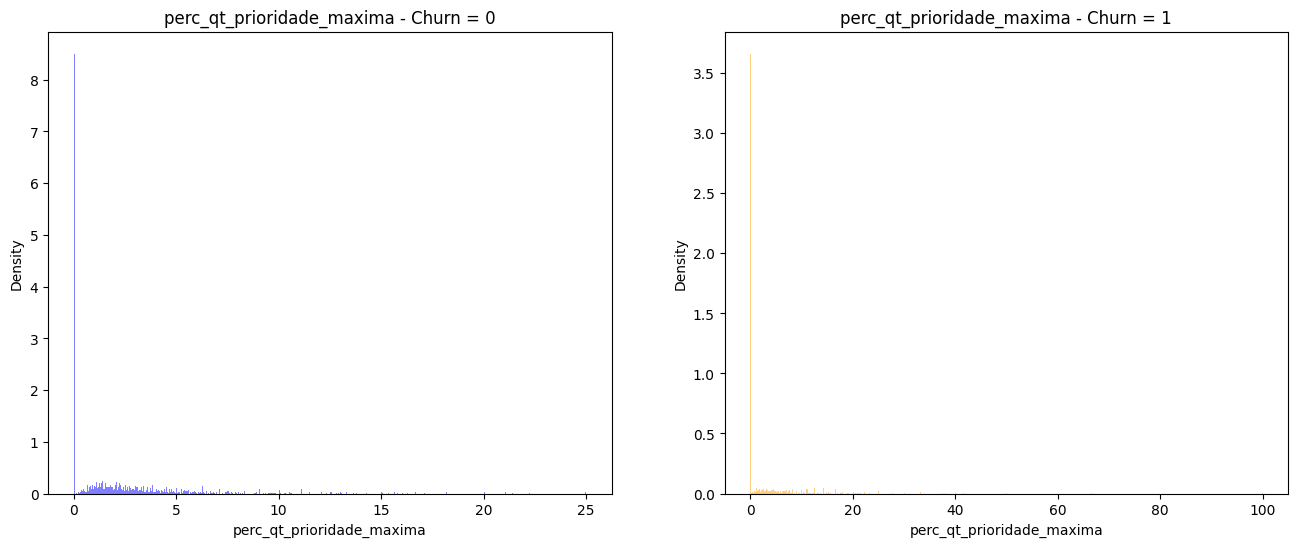

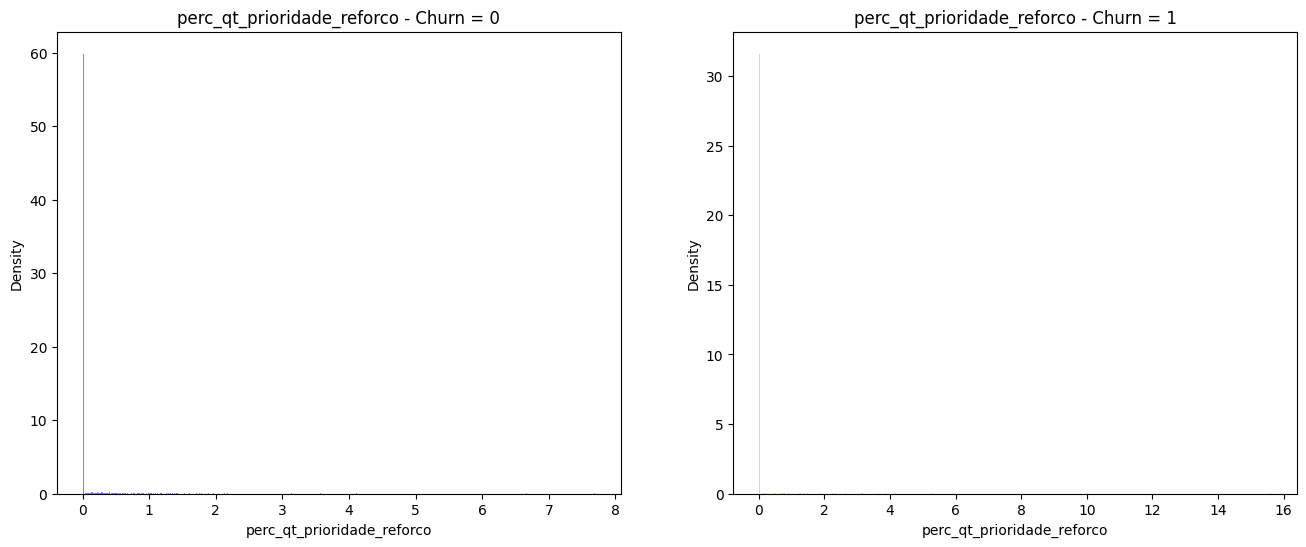

In [12]:
for col in dataset.drop(columns=['churn', 'cod_cliente']).columns:
    churn_0 = dataset[dataset['churn'] == 0][col]
    churn_1 = dataset[dataset['churn'] == 1][col]

    # Create histograms for each group
    plt.figure(figsize=(16, 6))

    plt.subplot(1, 2, 1)
    plt.hist(churn_0, bins=500, alpha=0.5, label='Churn = 0', color='blue', density=True)
    plt.title(f'{col} - Churn = 0')
    plt.xlabel(col)
    plt.ylabel('Density')

    plt.subplot(1, 2, 2)
    plt.hist(churn_1, bins=500, alpha=0.5, label='Churn = 1', color='orange', density=True)
    plt.title(f'{col} - Churn = 1')
    plt.xlabel(col)
    plt.ylabel('Density')

    plt.show()

## Distribuição do Tempo de Casa por Status de Churn

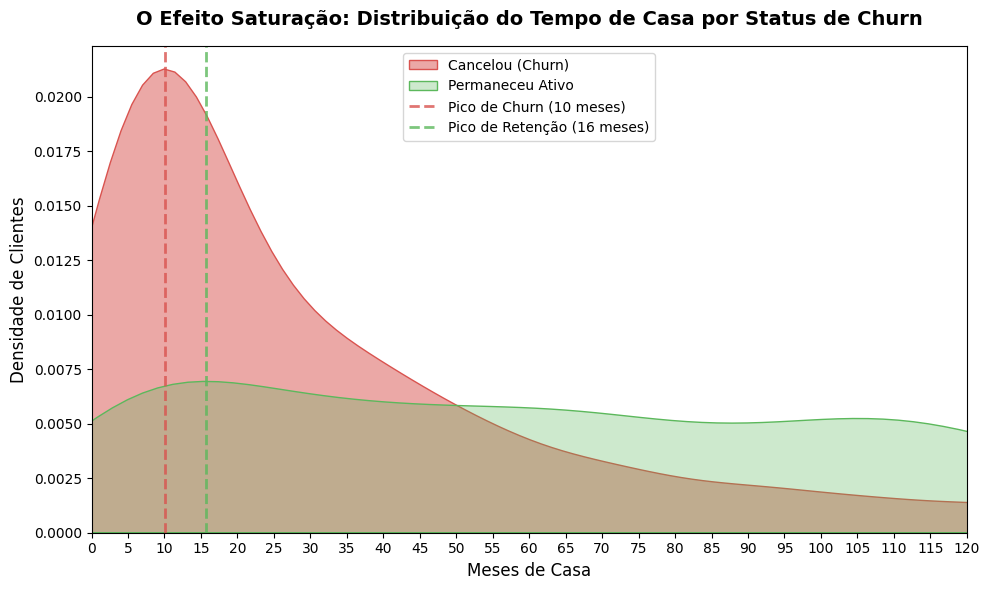

In [13]:
# Filtra os dados de cada grupo isolando os meses de casa
ativos = dataset[dataset['churn'] == 0]['meses_vida_cliente']
churns = dataset[dataset['churn'] == 1]['meses_vida_cliente']

# Grid de meses para o cálculo (0 a 120 meses)
valores_x = np.linspace(0, 120, 1000)

# CÁLCULO DO PICO DA CURVA VERDE (ATIVOS)
estimador_verde = gaussian_kde(ativos)
densidade_verde = estimador_verde(valores_x)
pico_verde      = valores_x[np.argmax(densidade_verde)]

# CÁLCULO DO PICO DA CURVA VERMELHA (CHURN)
estimador_vermelho = gaussian_kde(churns)
densidade_vermelha = estimador_vermelho(valores_x)
pico_vermelho      = valores_x[np.argmax(densidade_vermelha)]

# PLOTAGEM DO GRÁFICO
plt.figure(figsize=(10, 6))

# Filtra e plota a distribuição do tempo de casa para os dois grupos
sns.kdeplot(data=dataset[dataset['churn'] == 1],
            x='meses_vida_cliente',
            label='Cancelou (Churn)',
            fill=True,
            color='#d9534f',
            alpha=0.5)

sns.kdeplot(data=dataset[dataset['churn'] == 0],
            x='meses_vida_cliente',
            label='Permaneceu Ativo',
            fill=True,
            color='#5cb85c',
            alpha=0.3)

plt.title('O Efeito Saturação: Distribuição do Tempo de Casa por Status de Churn',
          fontsize=14,
          fontweight='bold',
          pad=15)
plt.xlabel('Meses de Casa', fontsize=12)
plt.ylabel('Densidade de Clientes', fontsize=12)
plt.xlim(0, 120)
plt.xticks(np.arange(0, 121, step=5))

# LINHAS VERTICAIS DOS PICOS
# Linha do Churn (Vermelha)
plt.axvline(pico_vermelho,
            color='#d9534f',
            linestyle='--',
            linewidth=2,
            alpha=0.8,
            label=f'Pico de Churn ({pico_vermelho:.0f} meses)')

# Linha dos Ativos (Verde)
plt.axvline(pico_verde,
            color='#5cb85c',
            linestyle='--',
            linewidth=2,
            alpha=0.8,
            label=f'Pico de Retenção ({pico_verde:.0f} meses)')

plt.legend(loc='upper center', fontsize=10)
plt.tight_layout()
plt.show()

# Features

In [14]:
X = dataset.drop(['cod_cliente', 'churn'], axis=1)
X

,valor_medio_contrato,meses_vida_cliente,qt_tarefas_total,media_dias_exec,qt_tarefas_sd,media_dias_exec_tarefa_sd,perc_qt_tarefas_sd,qt_tarefas_hd,media_dias_exec_tarefa_hd,perc_qt_tarefas_hd,...,media_dias_exec_bug,perc_qt_tarefas_bug,qt_categorias_distintas,qt_subcategorias_distintas,qt_grupos_envolvidos,perc_qt_prioridade_normal,perc_qt_prioridade_parcial,perc_qt_prioridade_urgente,perc_qt_prioridade_maxima,perc_qt_prioridade_reforco
0,1037.88,26,476,0.0840,0,0.0,0.0,0,0.0000,0.00000,...,0.0,0.0,3,6,3,100.00000,0.00000,0.00000,0.0,0.0
1,0.00,37,15,0.2667,0,0.0,0.0,11,0.3636,73.33333,...,0.0,0.0,4,7,4,80.00000,0.00000,20.00000,0.0,0.0
2,468.06,20,3,0.3333,0,0.0,0.0,0,0.0000,0.00000,...,0.0,0.0,3,3,1,66.66667,33.33333,0.00000,0.0,0.0
3,300.00,0,3,0.3333,0,0.0,0.0,0,0.0000,0.00000,...,0.0,0.0,3,3,1,100.00000,0.00000,0.00000,0.0,0.0
4,332.01,12,3,0.3333,0,0.0,0.0,0,0.0000,0.00000,...,0.0,0.0,3,3,0,100.00000,0.00000,0.00000,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4063,601.73,11,12,349.9167,0,0.0,0.0,1,0.0000,8.33333,...,0.0,0.0,7,9,5,91.66667,0.00000,8.33333,0.0,0.0
4064,40.00,1,3,352.3333,0,0.0,0.0,0,0.0000,0.00000,...,0.0,0.0,3,3,2,100.00000,0.00000,0.00000,0.0,0.0
4065,1051.78,15,1,357.0000,0,0.0,0.0,0,0.0000,0.00000,...,0.0,0.0,1,1,1,100.00000,0.00000,0.00000,0.0,0.0
4066,79.00,11,4,419.0000,0,0.0,0.0,1,27.0000,25.00000,...,0.0,0.0,2,2,4,100.00000,0.00000,0.00000,0.0,0.0


In [15]:
y = dataset['churn']

In [16]:
# Verificação de balanceamento da terget
total_clientes              = y.value_counts().sum()
total_clientes_churn        = y[y == 1].count()
total_clientes_nao_churn    = y[y == 0].count()

print(f'Total de clientes:                      {total_clientes}')
print(f'Porcentagem de clientes que não churn:  {total_clientes_nao_churn   / total_clientes * 100:.2f}%')
print(f'Porcentagem de clientes que churn:      {total_clientes_churn       / total_clientes * 100:.2f}%')

Total de clientes:                      4068
Porcentagem de clientes que não churn:  45.38%
Porcentagem de clientes que churn:      54.62%


# Análise de Correlação e Multicolinearidade

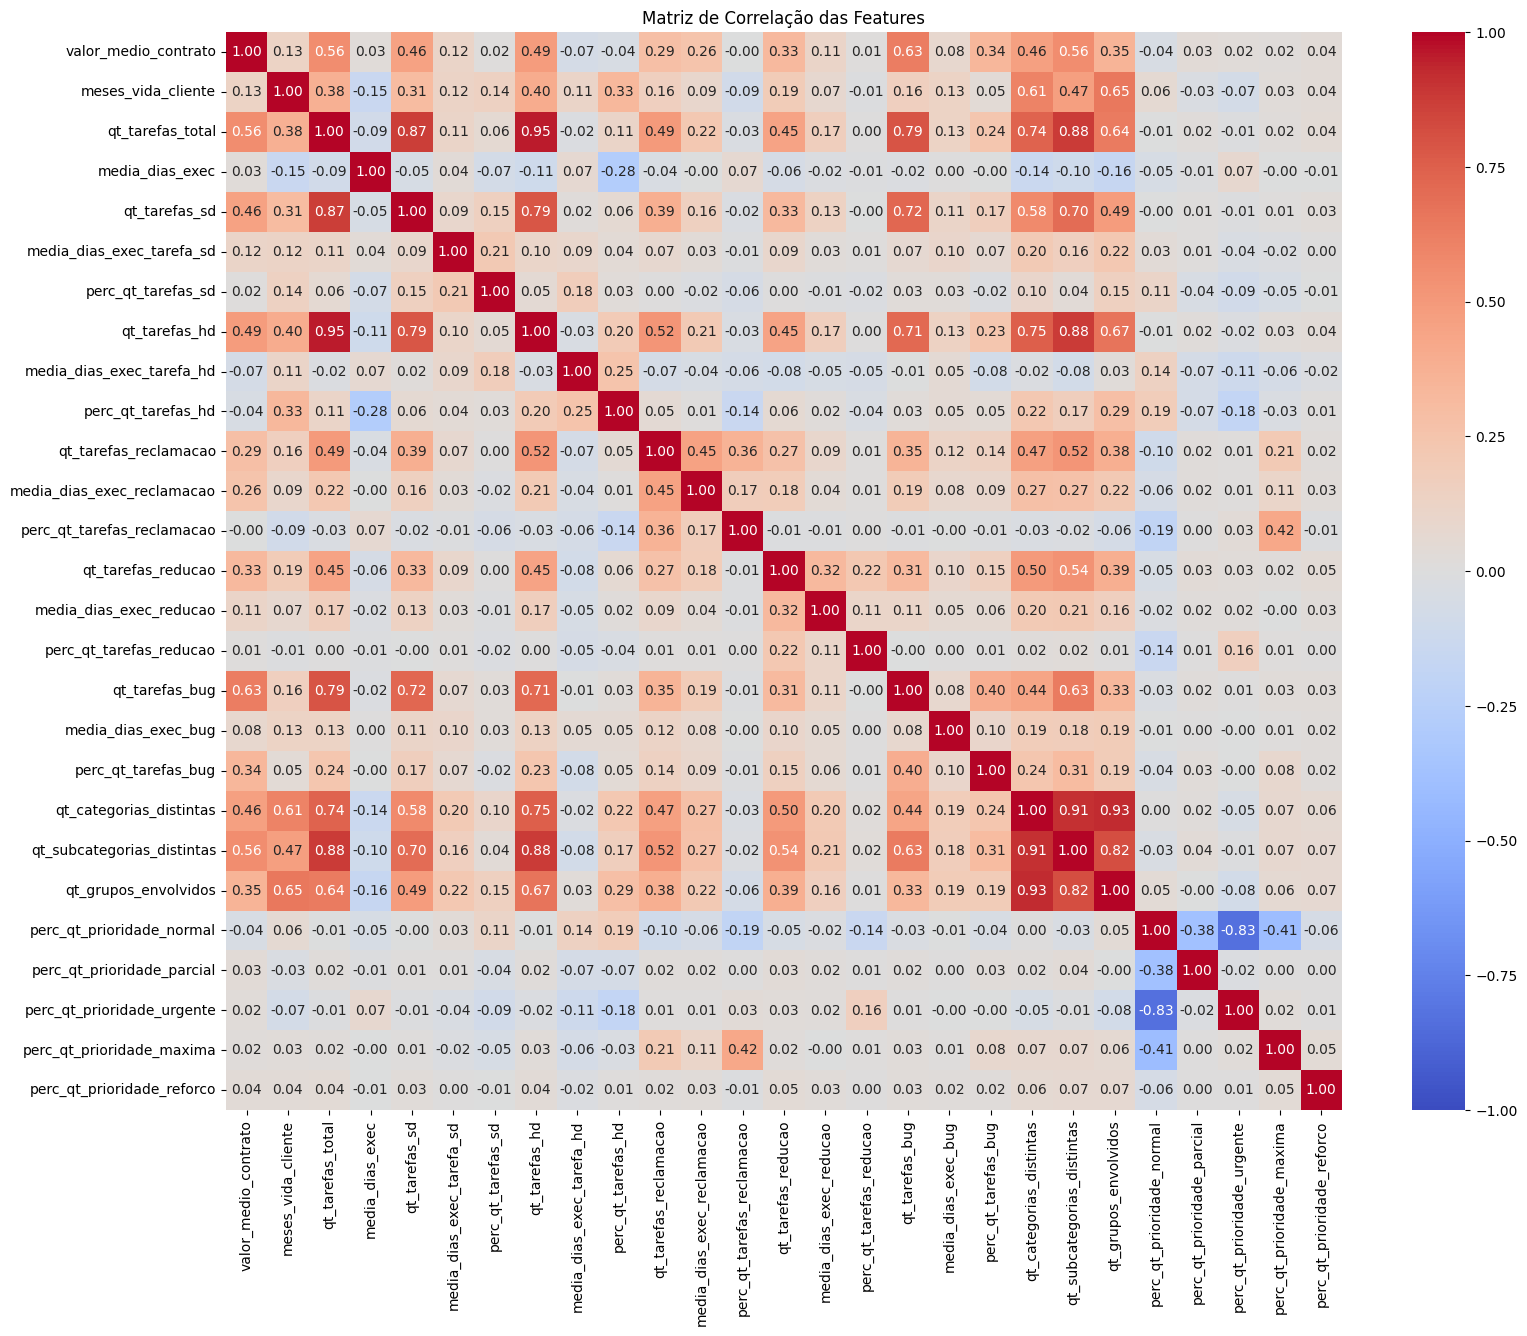

In [17]:
# Calculando a matriz de correlação de Pearson
plt.figure(figsize=(18, 14))
matrix_corr = X.corr()

# Plotando o Heatmap
sns.heatmap(matrix_corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matriz de Correlação das Features")
plt.show()

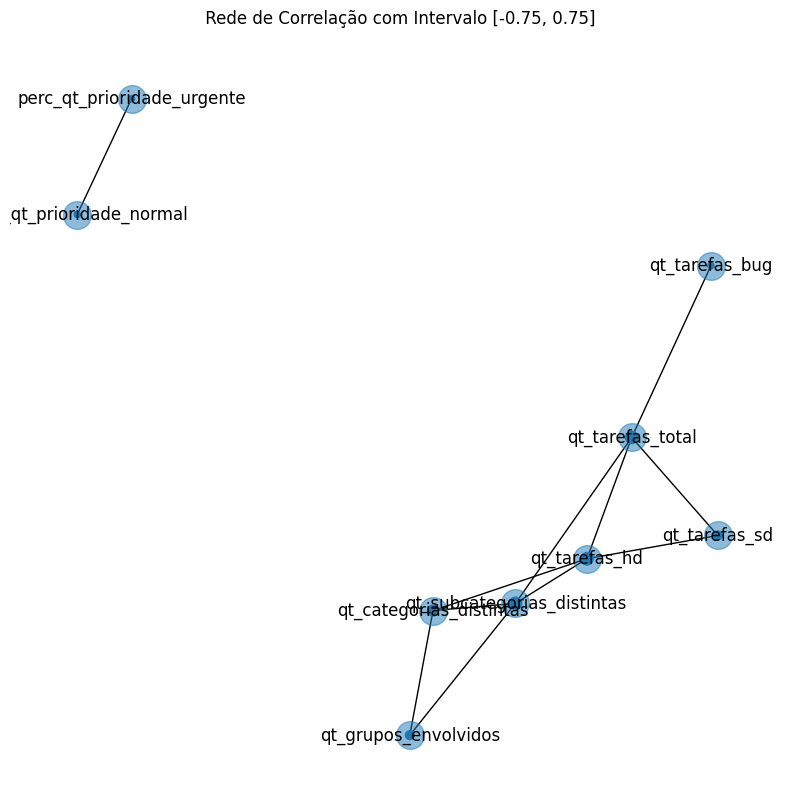

In [18]:
network_corr(X, matrix_corr, corr_interval=[-0.75, 0.75])

In [19]:
# Filtrando correlações altas
upper_tri = matrix_corr.where(np.triu(np.ones(matrix_corr.shape), k=1).astype(bool))
colunas_alta_corr = [column for column in upper_tri.columns if any(abs(upper_tri[column]) >= 0.75)]
print(f"Sugestão de variáveis para exclusão por alta correlação:\n{colunas_alta_corr}")

Sugestão de variáveis para exclusão por alta correlação:
['qt_tarefas_sd', 'qt_tarefas_hd', 'qt_tarefas_bug', 'qt_categorias_distintas', 'qt_subcategorias_distintas', 'qt_grupos_envolvidos', 'perc_qt_prioridade_urgente']


# Features Descartadas

In [20]:
# Verificação das colunas com zero inflation
total_linhas = X.shape[0]

colunas_zeros = {}
remove_colunas_zeros = []
for col in X.columns:
    linhas_zero = X[X[col] == 0][col].count()
    proporcao_zero = (linhas_zero / total_linhas).round(2)
    colunas_zeros[col] = proporcao_zero
    if proporcao_zero > 0.8:
        remove_colunas_zeros.append(col)

pd.DataFrame(list(colunas_zeros.items()),
    columns=['feature', 'proporcao_zeros']
    ).sort_values(by='proporcao_zeros', ascending=False).reset_index(drop=True)

,feature,proporcao_zeros
0,perc_qt_prioridade_reforco,0.96
1,media_dias_exec_reducao,0.91
2,perc_qt_tarefas_reducao,0.90
3,qt_tarefas_reducao,0.90
4,qt_tarefas_reclamacao,0.88
5,media_dias_exec_reclamacao,0.88
6,perc_qt_tarefas_reclamacao,0.88
7,media_dias_exec_bug,0.83
8,qt_tarefas_bug,0.81
9,perc_qt_tarefas_bug,0.81


In [21]:
remove_colunas_zeros

['qt_tarefas_reclamacao',
 'media_dias_exec_reclamacao',
 'perc_qt_tarefas_reclamacao',
 'qt_tarefas_reducao',
 'media_dias_exec_reducao',
 'perc_qt_tarefas_reducao',
 'qt_tarefas_bug',
 'media_dias_exec_bug',
 'perc_qt_tarefas_bug',
 'perc_qt_prioridade_reforco']

In [22]:
to_drop_completo = remove_colunas_zeros + colunas_alta_corr
to_drop_completo

['qt_tarefas_reclamacao',
 'media_dias_exec_reclamacao',
 'perc_qt_tarefas_reclamacao',
 'qt_tarefas_reducao',
 'media_dias_exec_reducao',
 'perc_qt_tarefas_reducao',
 'qt_tarefas_bug',
 'media_dias_exec_bug',
 'perc_qt_tarefas_bug',
 'perc_qt_prioridade_reforco',
 'qt_tarefas_sd',
 'qt_tarefas_hd',
 'qt_tarefas_bug',
 'qt_categorias_distintas',
 'qt_subcategorias_distintas',
 'qt_grupos_envolvidos',
 'perc_qt_prioridade_urgente']

In [23]:
X_limpo = X.drop(columns=to_drop_completo)
X_limpo.head()

,valor_medio_contrato,meses_vida_cliente,qt_tarefas_total,media_dias_exec,media_dias_exec_tarefa_sd,perc_qt_tarefas_sd,media_dias_exec_tarefa_hd,perc_qt_tarefas_hd,perc_qt_prioridade_normal,perc_qt_prioridade_parcial,perc_qt_prioridade_maxima
0,1037.88,26,476,0.0840,0.0,0.0,0.0000,0.00000,100.00000,0.00000,0.0
1,0.00,37,15,0.2667,0.0,0.0,0.3636,73.33333,80.00000,0.00000,0.0
2,468.06,20,3,0.3333,0.0,0.0,0.0000,0.00000,66.66667,33.33333,0.0
3,300.00,0,3,0.3333,0.0,0.0,0.0000,0.00000,100.00000,0.00000,0.0
4,332.01,12,3,0.3333,0.0,0.0,0.0000,0.00000,100.00000,0.00000,0.0


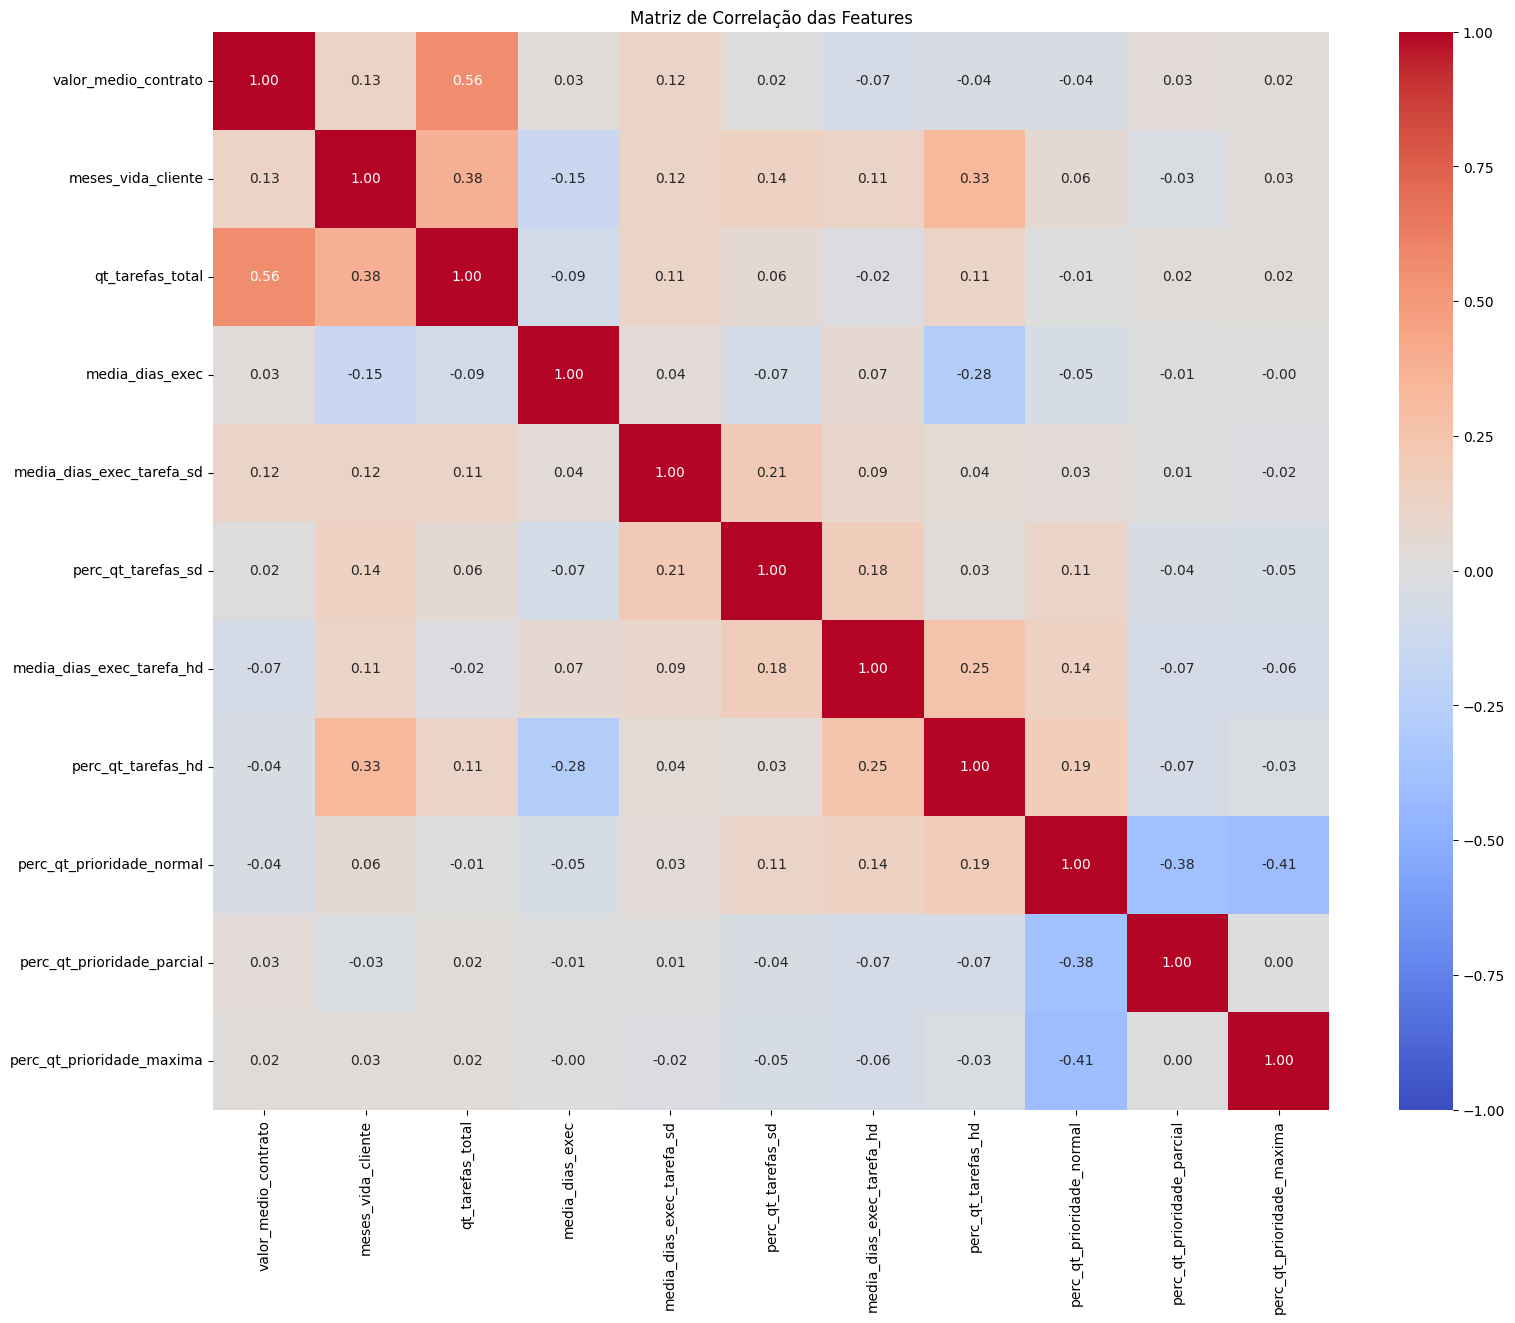

In [24]:
# Calculando a matriz de correlação de Pearson
plt.figure(figsize=(18, 14))
matrix_corr_limpa = X_limpo.corr()

# Plotando o Heatmap
sns.heatmap(matrix_corr_limpa, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matriz de Correlação das Features")
plt.show()

In [25]:
# Filtrando correlações altas
upper_tri_limpo = matrix_corr_limpa.where(np.triu(np.ones(matrix_corr_limpa.shape), k=1).astype(bool))

to_drop_2 = [column for column in upper_tri_limpo.columns if any(abs(upper_tri_limpo[column]) >= 0.75)]

print(f"Sugestão de variáveis para exclusão por alta correlação: {to_drop_2}")

Sugestão de variáveis para exclusão por alta correlação: []


# Análise de Outliers

In [26]:
# DataFrame com as colunas que restaram após o drop de correlação
df_features = X_limpo.copy()

print("--- ANÁLISE QUANTITATIVA DE OUTLIERS (MÉTODO IQR) ---")
print(f"{'Métrica / Feature':<40} | {'qt Outliers':<12} | {'Porcentagem':<12}")
print("-" * 62)

colunas_com_outliers_criticos = []

for col in df_features.columns:
    # Ignora colunas que já são flags binárias (0 ou 1), pois nelas não existem outliers estatísticos
    if df_features[col].nunique() <= 2:
        continue

    Q1 = df_features[col].quantile(0.25)
    Q3 = df_features[col].quantile(0.75)
    IQR = Q3 - Q1

    # Definição estatística de Outlier: além de 1.5 vezes o IQR
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = df_features[(df_features[col] < limite_inferior) | (df_features[col] > limite_superior)]
    total_outliers = len(outliers)
    porcentagem = (total_outliers / len(df_features)) * 100

    print(f"{col:<40} | {total_outliers:<12} | {porcentagem:.2f}%")

    # Se mais de 5% dos dados forem outliers, ou se houver um volume absoluto considerável
    if porcentagem > 5.0:
        colunas_com_outliers_criticos.append(col)

--- ANÁLISE QUANTITATIVA DE OUTLIERS (MÉTODO IQR) ---
Métrica / Feature                        | qt Outliers  | Porcentagem 
--------------------------------------------------------------
valor_medio_contrato                     | 436          | 10.72%
meses_vida_cliente                       | 71           | 1.75%
qt_tarefas_total                         | 469          | 11.53%
media_dias_exec                          | 345          | 8.48%
media_dias_exec_tarefa_sd                | 237          | 5.83%
perc_qt_tarefas_sd                       | 144          | 3.54%
media_dias_exec_tarefa_hd                | 147          | 3.61%
perc_qt_tarefas_hd                       | 0            | 0.00%
perc_qt_prioridade_normal                | 227          | 5.58%
perc_qt_prioridade_parcial               | 669          | 16.45%
perc_qt_prioridade_maxima                | 401          | 9.86%


In [27]:
# Dedivo à presença de outliers críticos,
# as variáveis numéricas serão padronizadas usando o RobustScaler,
# que é mais resistente a valores extremos para padronizar as features numéricas.

# Divisão de Treino/Teste e Padronização (Scaling)

In [28]:
# # Separando os dados em Treino e Teste garantindo a mesma proporção de Churn (stratify)
# X_train, X_test, y_train, y_test = train_test_split(
#     X_limpo, y, test_size=0.10, random_state=42, stratify=y
# )

# # Padronizando as variáveis
# scaler = RobustScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled  = scaler.transform(X_test)

# print(f"Base de Treino: {X_train_scaled.shape[0]} amostras")
# print(f"Base de Teste:  {X_test_scaled.shape[0]} amostras")

In [30]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_limpo, y, test_size=0.10, random_state=42, stratify=y
)

X_train, X_calib, y_train, y_calib = train_test_split(
    X_train_val, y_train_val, test_size=0.10, random_state=42, stratify=y_train_val
)

# Padronizando
scaler = MinMaxScaler()
# scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_calib_scaled = scaler.transform(X_calib)
X_test_scaled  = scaler.transform(X_test)

print(f"Base de Treino:      {X_train_scaled.shape[0]} amostras")
print(f"Base de Calibração:  {X_calib_scaled.shape[0]} amostras")
print(f"Base de Teste:       {X_test_scaled.shape[0]} amostras")

Base de Treino:      3294 amostras
Base de Calibração:  367 amostras
Base de Teste:       407 amostras


## Salva Scaler

In [31]:
joblib.dump(scaler, 'src\\scaler_producao.pkl')

['src\\scaler_producao.pkl']

## Salva Features do Modelo

In [32]:
# Extrai os nomes das colunas na ordem exata do modelo
features_modelo = list(X_test.columns)

# Salva em um arquivo JSON
with open('src\\features_modelo.json', 'w', encoding='utf-8') as f:
    json.dump(features_modelo, f, ensure_ascii=False, indent=4)

# Regressão Logística

In [33]:
df_X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_train_sm        = sm.add_constant(df_X_train_scaled)
X_train_sm        = pd.DataFrame(X_train_sm, columns=['const'] + list(df_X_train_scaled.columns))

modelo_reglog = sm.Logit(y_train, X_train_sm).fit(method='bfgs', maxiter=1000)

Optimization terminated successfully.
         Current function value: 0.461186
         Iterations: 144
         Function evaluations: 145
         Gradient evaluations: 145


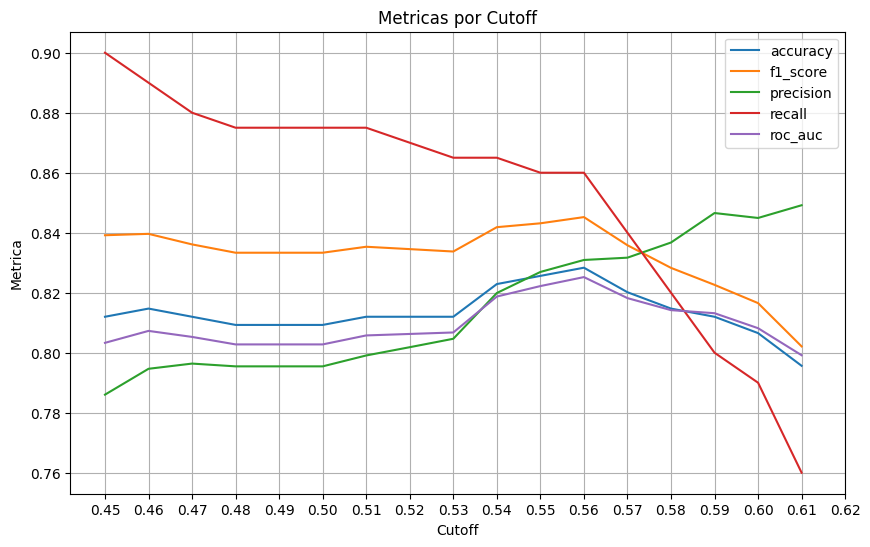

In [34]:
df_X_calib_scaled = pd.DataFrame(X_calib_scaled, columns=X_calib.columns, index=X_calib.index)
X_calib_sm        = sm.add_constant(df_X_calib_scaled)
X_calib_sm        = pd.DataFrame(X_calib_sm, columns=['const'] + list(df_X_calib_scaled.columns))

y_probs_reglog_calib = modelo_reglog.predict(X_calib_sm)
analise_cutoff(y_calib, y_probs_reglog_calib, min_cutoff=0.45, max_cutoff=0.62, passo=0.01)

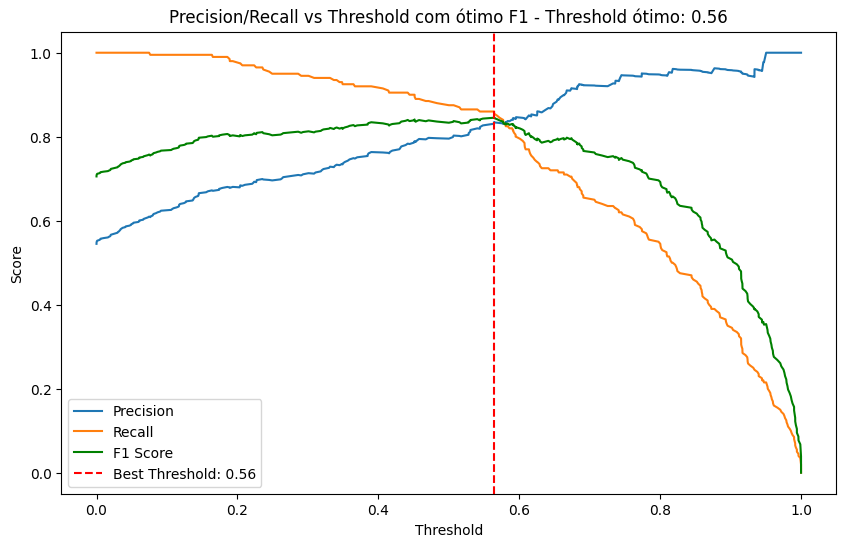

In [35]:
best_threshold_reglog = plot_precision_recall_curve(y_calib, y_probs_reglog_calib)

In [36]:
df_X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)
X_test_sm        = sm.add_constant(df_X_test_scaled)
X_test_sm        = pd.DataFrame(X_test_sm, columns=['const'] + list(df_X_test_scaled.columns))

y_probs_reglog = modelo_reglog.predict(X_test_sm)
y_pred_reglog  = (y_probs_reglog >= best_threshold_reglog).astype(int)

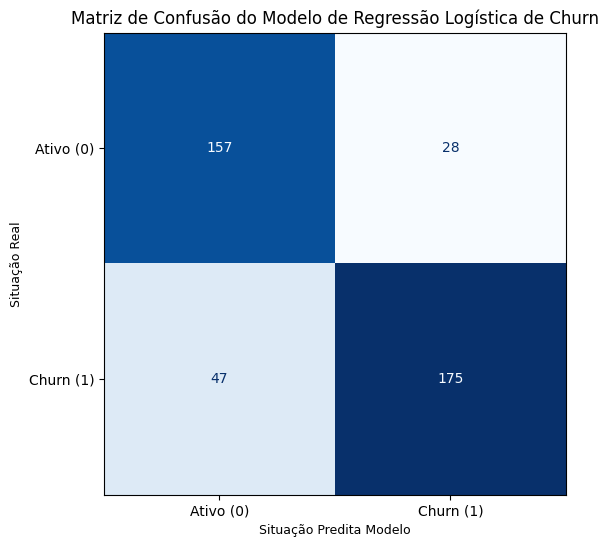

In [37]:
# Matriz de Confusão
cm_reglog = confusion_matrix(y_test, y_pred_reglog.values)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_reglog, display_labels=['Ativo (0)', 'Churn (1)'])
fig, ax = plt.subplots(figsize=(6, 6))
ax.grid(False)
disp.plot(cmap='Blues', values_format='d', colorbar=False, ax=ax)
plt.title('Matriz de Confusão do Modelo de Regressão Logística de Churn')
plt.ylabel('Situação Real', fontsize=9)
plt.xlabel('Situação Predita Modelo', fontsize=9)
plt.show()

ROC AUC Score: 0.90


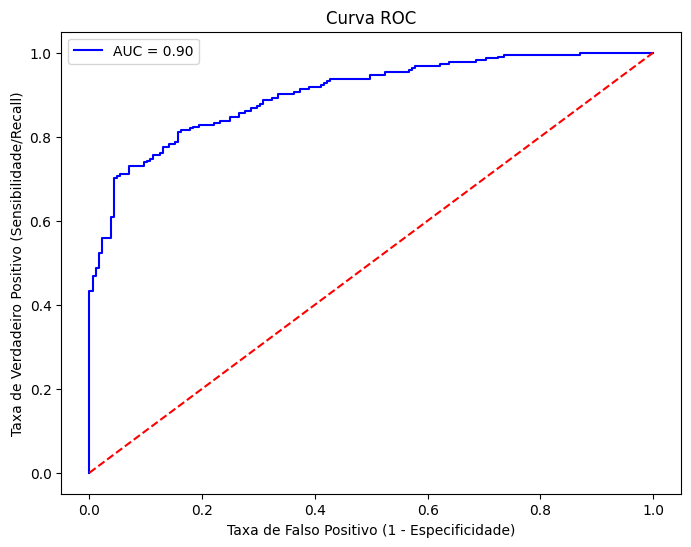

In [38]:
plot_curva_roc_auc(y_test, y_probs_reglog)

In [39]:
# Relatório de Classificação (Precision, Recall, F1-Score)
print(classification_report(y_test, y_pred_reglog))

              precision    recall  f1-score   support

           0       0.77      0.85      0.81       185
           1       0.86      0.79      0.82       222

    accuracy                           0.82       407
   macro avg       0.82      0.82      0.82       407
weighted avg       0.82      0.82      0.82       407



In [40]:
recall_reglog   = recall_score(y_test, y_pred_reglog)
precisao_reglog = precision_score(y_test, y_pred_reglog)
acuracia_reglog = accuracy_score(y_test, y_pred_reglog)
f1_score_reglog = f1_score(y_test, y_pred_reglog)
roc_auc_reglog  = roc_auc_score(y_test, y_probs_reglog)

## Salva Modelo

In [41]:
joblib.dump(modelo_reglog, 'src\\modelo_reglog.pkl')

['src\\modelo_reglog.pkl']

## Importância das Features

In [42]:
# Extraindo Coeficientes e p-valores
df_importance = pd.DataFrame({
    'Feature':      df_X_train_scaled.columns,
    'Coefficient':  modelo_reglog.params.drop('const'),
    'p_value':      modelo_reglog.pvalues.drop('const')
}).reset_index(drop=True)

# Criando critério de significância estatística (p-valor < 0.05)
df_importance['Significativo'] = df_importance['p_value'].apply(
    lambda x: 'Sim (p < 0.05)' if x < 0.05 else 'Não (Irrelevante)'
    )

# Exibir tabela textual complementar
print(df_importance[['Feature', 'Coefficient', 'p_value', 'Significativo']].to_string(index=False))

                   Feature  Coefficient      p_value     Significativo
      valor_medio_contrato   -22.573805 9.991547e-11    Sim (p < 0.05)
        meses_vida_cliente    -8.396964 2.190376e-77    Sim (p < 0.05)
          qt_tarefas_total    -7.958991 1.874619e-04    Sim (p < 0.05)
           media_dias_exec     4.382938 8.853821e-06    Sim (p < 0.05)
 media_dias_exec_tarefa_sd    -3.373921 5.877587e-03    Sim (p < 0.05)
        perc_qt_tarefas_sd     3.912086 8.415369e-09    Sim (p < 0.05)
 media_dias_exec_tarefa_hd    13.854913 1.744972e-47    Sim (p < 0.05)
        perc_qt_tarefas_hd     0.221089 3.020365e-01 Não (Irrelevante)
 perc_qt_prioridade_normal     3.171395 2.695840e-08    Sim (p < 0.05)
perc_qt_prioridade_parcial    -2.700768 2.028913e-01 Não (Irrelevante)
 perc_qt_prioridade_maxima     7.194828 1.374037e-08    Sim (p < 0.05)


In [43]:
remove_colunas_nao_importantes = list(df_importance[df_importance['p_value'] > 0.05]['Feature'])
remove_colunas_nao_importantes

['perc_qt_tarefas_hd', 'perc_qt_prioridade_parcial']

In [44]:
X_train_scaled_logreg  = X_train_sm.drop(columns=remove_colunas_nao_importantes)
X_test_scaled_logreg   = X_test_sm.drop(columns=remove_colunas_nao_importantes)

modelo_reglog_limpo = sm.Logit(y_train, X_train_scaled_logreg).fit(method='bfgs', maxiter=1000)

y_probs_reglog_limpo = modelo_reglog_limpo.predict(X_test_scaled_logreg)

Optimization terminated successfully.
         Current function value: 0.461641
         Iterations: 136
         Function evaluations: 137
         Gradient evaluations: 137


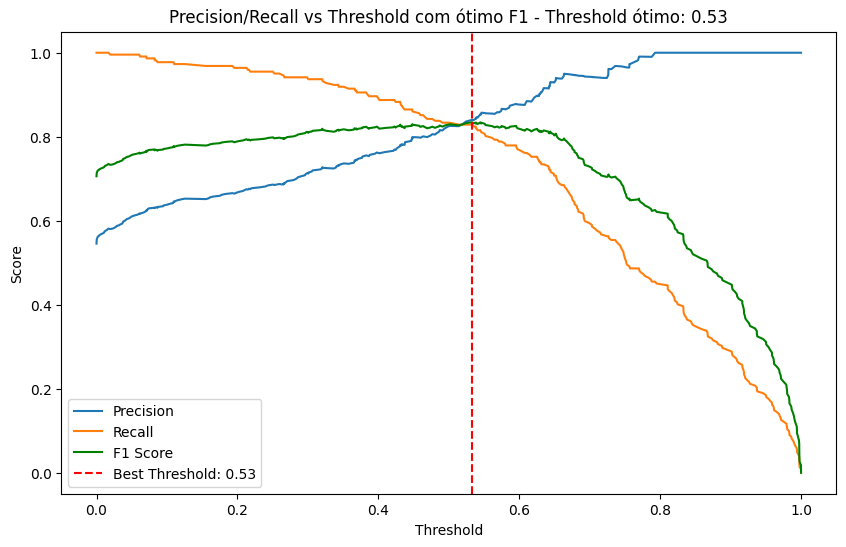

In [45]:
best_threshold_reglog_limpo = plot_precision_recall_curve(y_test, y_probs_reglog_limpo)

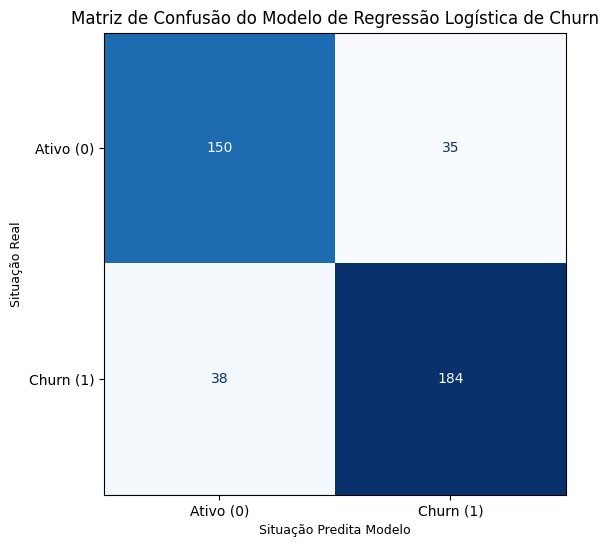

In [46]:
y_pred_reglog_limpo = (y_probs_reglog_limpo >= best_threshold_reglog_limpo).astype(int)

# Matriz de Confusão
cm_reglog_limpo = confusion_matrix(y_test, y_pred_reglog_limpo.values)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_reglog_limpo, display_labels=['Ativo (0)', 'Churn (1)'])
fig, ax = plt.subplots(figsize=(6, 6))
ax.grid(False)

disp.plot(cmap='Blues', values_format='d', colorbar=False, ax=ax) # 'd' força a exibição como número inteiro

plt.title('Matriz de Confusão do Modelo de Regressão Logística de Churn')
plt.ylabel('Situação Real', fontsize=9)
plt.xlabel('Situação Predita Modelo', fontsize=9)
plt.show()

ROC AUC Score: 0.90


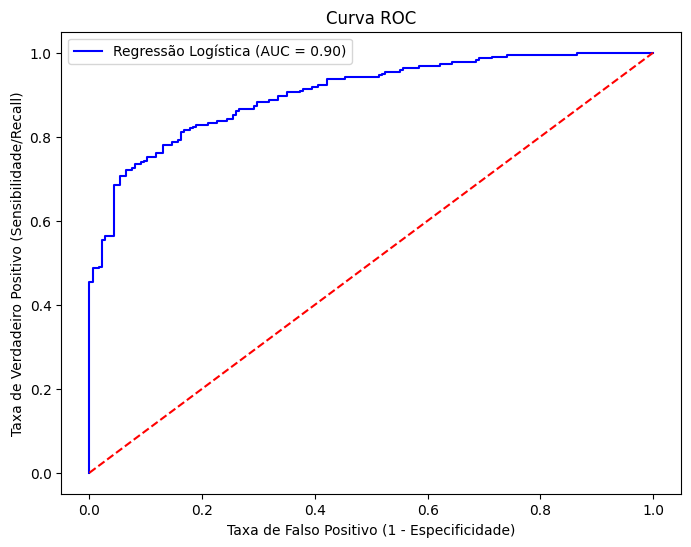

In [47]:
# ROC AUC Score
auc = roc_auc_score(y_test, y_probs_reglog_limpo)
print(f"ROC AUC Score: {auc:.2f}")

# Plotando a Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_probs_reglog_limpo)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'Regressão Logística (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('Taxa de Falso Positivo (1 - Especificidade)')
plt.ylabel('Taxa de Verdadeiro Positivo (Sensibilidade/Recall)')
plt.title('Curva ROC')
plt.legend()
plt.show()

In [48]:
# Relatório de Classificação (Precision, Recall, F1-Score)
print(classification_report(y_test, y_pred_reglog_limpo))

              precision    recall  f1-score   support

           0       0.80      0.81      0.80       185
           1       0.84      0.83      0.83       222

    accuracy                           0.82       407
   macro avg       0.82      0.82      0.82       407
weighted avg       0.82      0.82      0.82       407



In [49]:
recall_reglog_limpo   = recall_score(y_test, y_pred_reglog_limpo)
precisao_reglog_limpo = precision_score(y_test, y_pred_reglog_limpo)
acuracia_reglog_limpo = accuracy_score(y_test, y_pred_reglog_limpo)
f1_score_reglog_limpo = f1_score(y_test, y_pred_reglog_limpo)
roc_auc_reglog_limpo  = roc_auc_score(y_test, y_probs_reglog_limpo)

In [50]:
# Extraindo Coeficientes e p-valores
df_importance_reglog_limpo = pd.DataFrame({
    'Feature':      X_train_scaled_logreg.drop(columns=['const']).columns,
    'Coefficient':  modelo_reglog_limpo.params.drop('const'),
    'p_value':      modelo_reglog_limpo.pvalues.drop('const')
}).reset_index(drop=True)

# Criando critério de significância estatística (p-valor < 0.05)
df_importance_reglog_limpo['Significativo'] = df_importance_reglog_limpo['p_value'].apply(
    lambda x: 'Sim (p < 0.05)' if x < 0.05 else 'Não (Irrelevante)'
    )

# Exibir tabela textual complementar
print(df_importance_reglog_limpo[['Feature', 'Coefficient', 'p_value', 'Significativo']].to_string(index=False))

                  Feature  Coefficient      p_value  Significativo
     valor_medio_contrato   -23.119445 3.858294e-11 Sim (p < 0.05)
       meses_vida_cliente    -8.292050 6.514619e-80 Sim (p < 0.05)
         qt_tarefas_total    -7.679614 2.367236e-04 Sim (p < 0.05)
          media_dias_exec     4.131445 1.050667e-05 Sim (p < 0.05)
media_dias_exec_tarefa_sd    -3.458608 4.246185e-03 Sim (p < 0.05)
       perc_qt_tarefas_sd     3.884791 1.032635e-08 Sim (p < 0.05)
media_dias_exec_tarefa_hd    14.072112 1.333252e-50 Sim (p < 0.05)
perc_qt_prioridade_normal     3.464956 8.201853e-10 Sim (p < 0.05)
perc_qt_prioridade_maxima     7.476665 4.787582e-09 Sim (p < 0.05)


## Salva Modelo

In [51]:
joblib.dump(modelo_reglog_limpo, 'src\\modelo_reglog_limpo.pkl')

['src\\modelo_reglog_limpo.pkl']

# Random Forest Classifier

In [52]:
modelo_rf = RandomForestClassifier(
    n_estimators=200,      # Quantidade de árvores na floresta
    max_depth=8,           # Limite sênior para não deixar a árvore "decorar" ruídos
    min_samples_leaf=5,    # Garante que cada folha tenha um grupo seguro de clientes
    random_state=42,
    n_jobs=-1              # Usa todos os núcleos do seu processador
)

modelo_rf.fit(X_train_scaled, y_train)

y_pred_rf  = modelo_rf.predict(X_test_scaled)
y_probs_rf = modelo_rf.predict_proba(X_test_scaled)[:, 1]

## Métricas

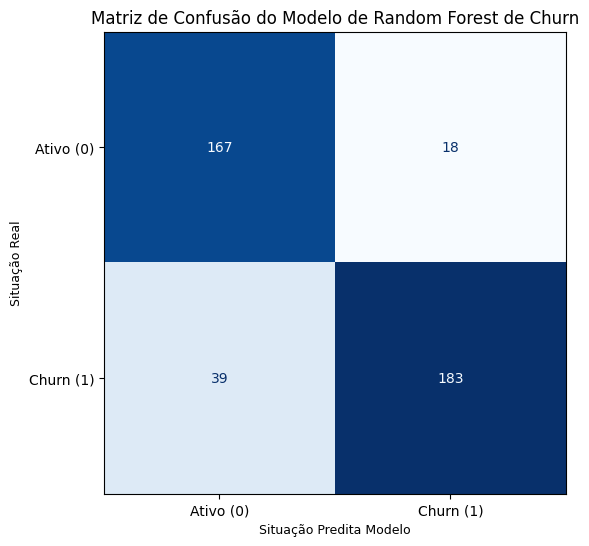

In [53]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Ativo (0)', 'Churn (1)'])
fig, ax = plt.subplots(figsize=(6, 6))
ax.grid(False)

disp.plot(cmap='Blues', values_format='d', colorbar=False, ax=ax) # 'd' força a exibição como número inteiro

plt.title('Matriz de Confusão do Modelo de Random Forest de Churn')
plt.ylabel('Situação Real', fontsize=9)
plt.xlabel('Situação Predita Modelo', fontsize=9)
plt.show()

ROC AUC Score: 0.93


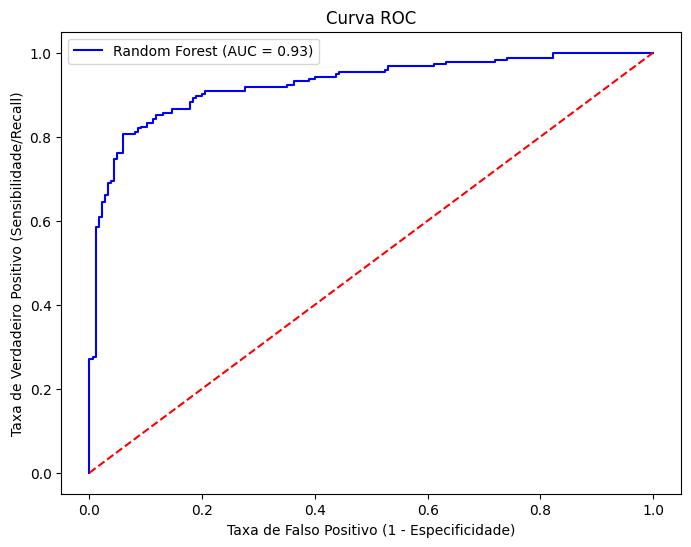

In [54]:
# ROC AUC Score
auc = roc_auc_score(y_test, y_probs_rf)
print(f"ROC AUC Score: {auc:.2f}")

# Plotando a Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_probs_rf)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'Random Forest (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('Taxa de Falso Positivo (1 - Especificidade)')
plt.ylabel('Taxa de Verdadeiro Positivo (Sensibilidade/Recall)')
plt.title('Curva ROC')
plt.legend()
plt.show()

In [55]:
# Relatório de Classificação (Precision, Recall, F1-Score)
print("--- RELATÓRIO DE CLASSIFICAÇÃO ---")
print(classification_report(y_test, y_pred_rf))

--- RELATÓRIO DE CLASSIFICAÇÃO ---
              precision    recall  f1-score   support

           0       0.81      0.90      0.85       185
           1       0.91      0.82      0.87       222

    accuracy                           0.86       407
   macro avg       0.86      0.86      0.86       407
weighted avg       0.87      0.86      0.86       407



In [56]:
recall_rf   = recall_score(y_test, y_pred_rf)
precisao_rf = precision_score(y_test, y_pred_rf)
acuracia_rf = accuracy_score(y_test, y_pred_rf)
f1_score_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf  = roc_auc_score(y_test, y_probs_rf)

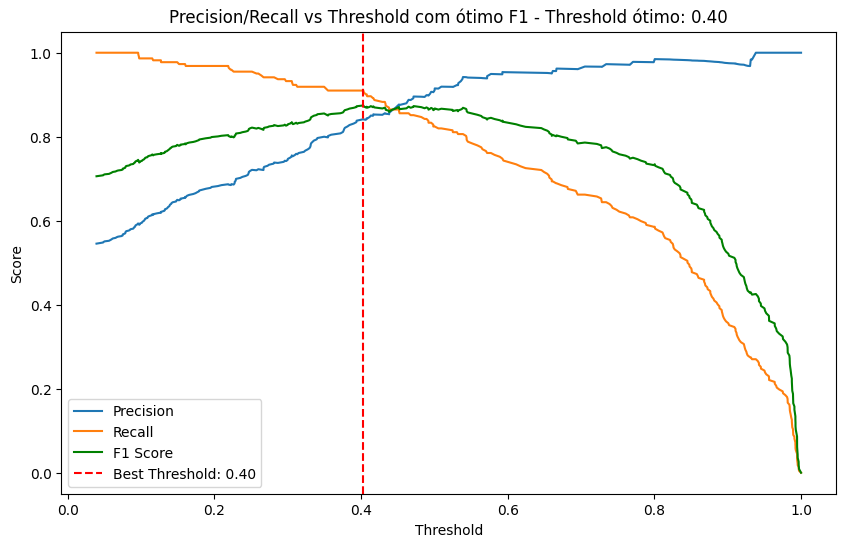

In [57]:
best_threshold_rf = plot_precision_recall_curve(y_test, y_probs_rf)

## Importância das Features

In [58]:
# Extraindo a importância real das features (substituindo o .coef_)
importancia_features = modelo_rf.feature_importances_

# Montando o novo DataFrame sênior de impacto
coeficientes_churn_rf = pd.DataFrame({
    'Feature': X_limpo.columns,
    'Importancia_Absoluta': importancia_features # Guardamos o valor bruto para ordenação
})

# Transformando em porcentagem de impacto na decisão do modelo
coeficientes_churn_rf['Importancia_Percentual'] = (coeficientes_churn_rf['Importancia_Absoluta'] * 100).round(2)

# Cria o texto formatado indicando o peso da variável na tomada de decisão
coeficientes_churn_rf['Importancia_Formatado'] = coeficientes_churn_rf['Importancia_Percentual'].astype(str) + "% de peso no modelo"

# Ordena da feature MAIS importante para a MENOS importante
coeficientes_churn_rf = coeficientes_churn_rf.sort_values(by='Importancia_Absoluta', ascending=False).reset_index(drop=True)

# coeficientes_churn_rf.to_csv('dados_resultado\\importancia_churn_rf.csv', index=False)
coeficientes_churn_rf

,Feature,Importancia_Absoluta,Importancia_Percentual,Importancia_Formatado
0,valor_medio_contrato,0.210474,21.05,21.05% de peso no modelo
1,qt_tarefas_total,0.188259,18.83,18.83% de peso no modelo
2,meses_vida_cliente,0.168798,16.88,16.88% de peso no modelo
3,media_dias_exec_tarefa_hd,0.116722,11.67,11.67% de peso no modelo
4,perc_qt_prioridade_normal,0.094109,9.41,9.41% de peso no modelo
5,perc_qt_prioridade_parcial,0.045787,4.58,4.58% de peso no modelo
6,perc_qt_tarefas_hd,0.043945,4.39,4.39% de peso no modelo
7,media_dias_exec,0.042148,4.21,4.21% de peso no modelo
8,perc_qt_prioridade_maxima,0.040248,4.02,4.02% de peso no modelo
9,perc_qt_tarefas_sd,0.028508,2.85,2.85% de peso no modelo


## Salva Modelo

In [59]:
joblib.dump(modelo_rf, 'src\\modelo_rf.pkl')

['src\\modelo_rf.pkl']

# XGBoost

In [60]:
# Para lidar com o desbalanceamento, calculamos o scale_pos_weight
scale_pos_weight = total_clientes_churn / total_clientes_nao_churn

# Instanciando o modelo puro
modelo_xgb = XGBClassifier(
    random_state=42,
    n_estimators=150,
    max_depth=5,                        # Árvores do XGBoost são mais rasas por natureza
    learning_rate=0.05,                 # Passos mais lentos para aprender com precisão
    subsample=0.8,                      # Amostra aleatória de 80% dos dados para cada árvore
    colsample_bytree=0.8,               # Amostra aleatória de 80% das features para cada árvore
    eval_metric='logloss',              # Métrica padrão para probabilidade
    scale_pos_weight=scale_pos_weight   # Ajuste para lidar com o desbalanceamento
)

modelo_xgb.fit(X_train, y_train)

y_pred_xgb  = modelo_xgb.predict(X_test)
y_probs_xgb = modelo_xgb.predict_proba(X_test)[:, 1]


## Métricas

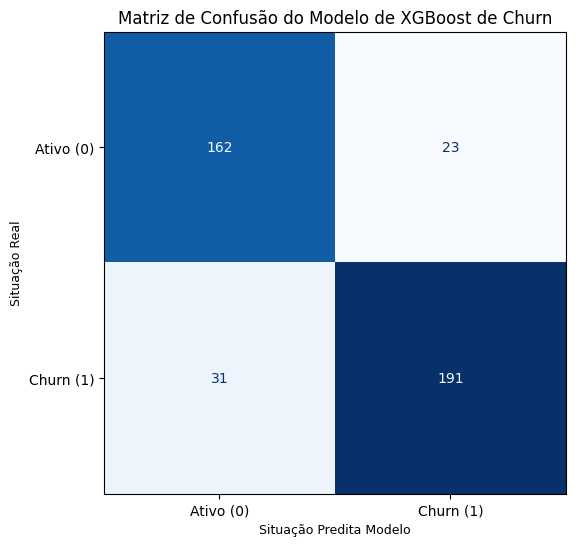

In [61]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=['Ativo (0)', 'Churn (1)'])
fig, ax = plt.subplots(figsize=(6, 6))
ax.grid(False)

disp.plot(cmap='Blues', values_format='d', colorbar=False, ax=ax) # 'd' força a exibição como número inteiro

plt.title('Matriz de Confusão do Modelo de XGBoost de Churn')
plt.ylabel('Situação Real', fontsize=9)
plt.xlabel('Situação Predita Modelo', fontsize=9)
plt.show()

ROC AUC Score: 0.94


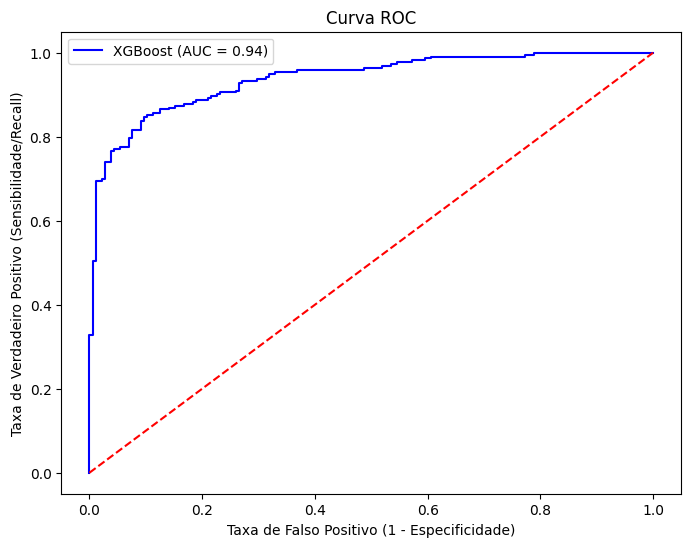

In [62]:
# ROC AUC Score
auc = roc_auc_score(y_test, y_probs_xgb)
print(f"ROC AUC Score: {auc:.2f}")

# Plotando a Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_probs_xgb)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'XGBoost (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('Taxa de Falso Positivo (1 - Especificidade)')
plt.ylabel('Taxa de Verdadeiro Positivo (Sensibilidade/Recall)')
plt.title('Curva ROC')
plt.legend()
plt.show()

In [63]:
# Relatório de Classificação (Precision, Recall, F1-Score)
print("--- RELATÓRIO DE CLASSIFICAÇÃO ---")
print(classification_report(y_test, y_pred_xgb))

--- RELATÓRIO DE CLASSIFICAÇÃO ---
              precision    recall  f1-score   support

           0       0.84      0.88      0.86       185
           1       0.89      0.86      0.88       222

    accuracy                           0.87       407
   macro avg       0.87      0.87      0.87       407
weighted avg       0.87      0.87      0.87       407



In [64]:
recall_xgb   = recall_score(y_test, y_pred_xgb)
precisao_xgb = precision_score(y_test, y_pred_xgb)
acuracia_xgb = accuracy_score(y_test, y_pred_xgb)
f1_score_xgb = f1_score(y_test, y_pred_xgb)
roc_auc_xgb  = roc_auc_score(y_test, y_probs_xgb)

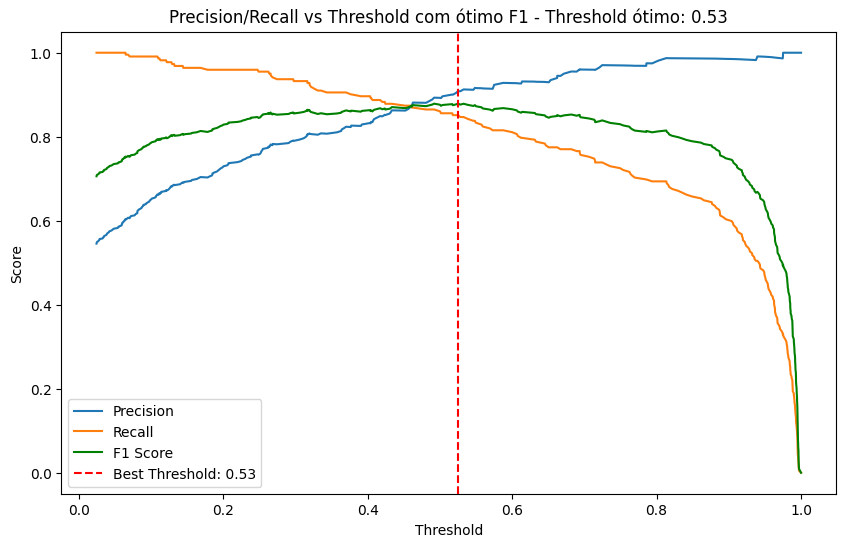

In [65]:
best_threshold_xgb = plot_precision_recall_curve(y_test, y_probs_xgb)

## Importância das Features

In [66]:
# Extraindo a importância real das features do XGBoost
importancia_features_xgb = modelo_xgb.feature_importances_

# Montando o DataFrame de Impacto do XGBoost
coeficientes_churn_xgb = pd.DataFrame({
    'Feature': X_limpo.columns,
    'Importancia_Absoluta': importancia_features_xgb
})

# Transformando em porcentagem de impacto na decisão
coeficientes_churn_xgb['Importancia_Percentual'] = (coeficientes_churn_xgb['Importancia_Absoluta'] * 100).round(2)

# Criando o texto formatado para o relatório
coeficientes_churn_xgb['Importancia_Formatado'] = coeficientes_churn_xgb['Importancia_Percentual'].astype(str) + "% de peso no modelo"

# Ordenando da feature MAIS importante para a MENOS importante
coeficientes_churn_xgb = coeficientes_churn_xgb.sort_values(by='Importancia_Absoluta', ascending=False).reset_index(drop=True)

# Exibe o resultado na tela
coeficientes_churn_xgb

,Feature,Importancia_Absoluta,Importancia_Percentual,Importancia_Formatado
0,valor_medio_contrato,0.199579,19.959999,19.96% de peso no modelo
1,meses_vida_cliente,0.160497,16.049999,16.05% de peso no modelo
2,qt_tarefas_total,0.128595,12.860000,12.86% de peso no modelo
3,media_dias_exec_tarefa_hd,0.116325,11.630000,11.63% de peso no modelo
4,perc_qt_prioridade_normal,0.078564,7.860000,7.86% de peso no modelo
5,perc_qt_prioridade_maxima,0.065550,6.550000,6.55% de peso no modelo
6,perc_qt_tarefas_hd,0.057425,5.740000,5.74% de peso no modelo
7,perc_qt_prioridade_parcial,0.052456,5.250000,5.25% de peso no modelo
8,media_dias_exec,0.050221,5.020000,5.02% de peso no modelo
9,perc_qt_tarefas_sd,0.045833,4.580000,4.58% de peso no modelo


## Salva Modelo

In [67]:
joblib.dump(modelo_xgb, 'src\\modelo_xgb.pkl')

['src\\modelo_xgb.pkl']

## Análise SHAP

--- VISÃO GLOBAL DE IMPACTO DAS FEATURES ---


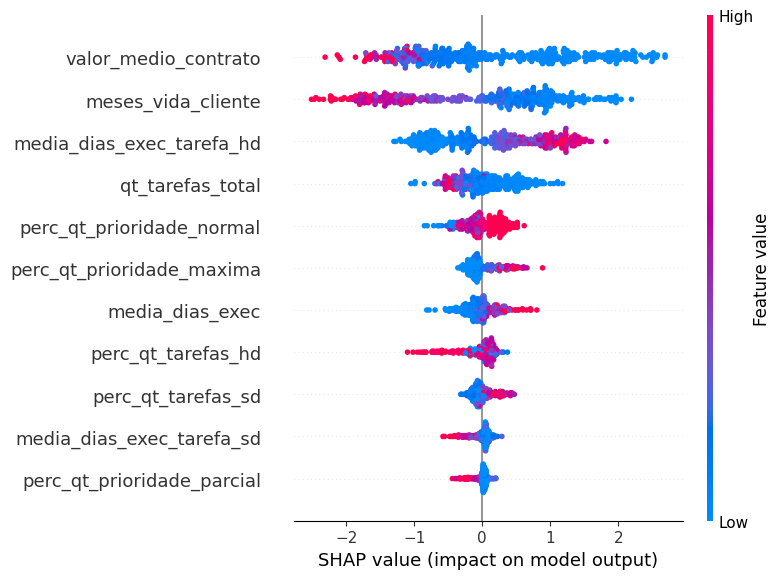


--- AUDITORIA INDIVIDUAL: POR QUE ESTE CLIENTE RECEBEU ESSE SCORE? ---


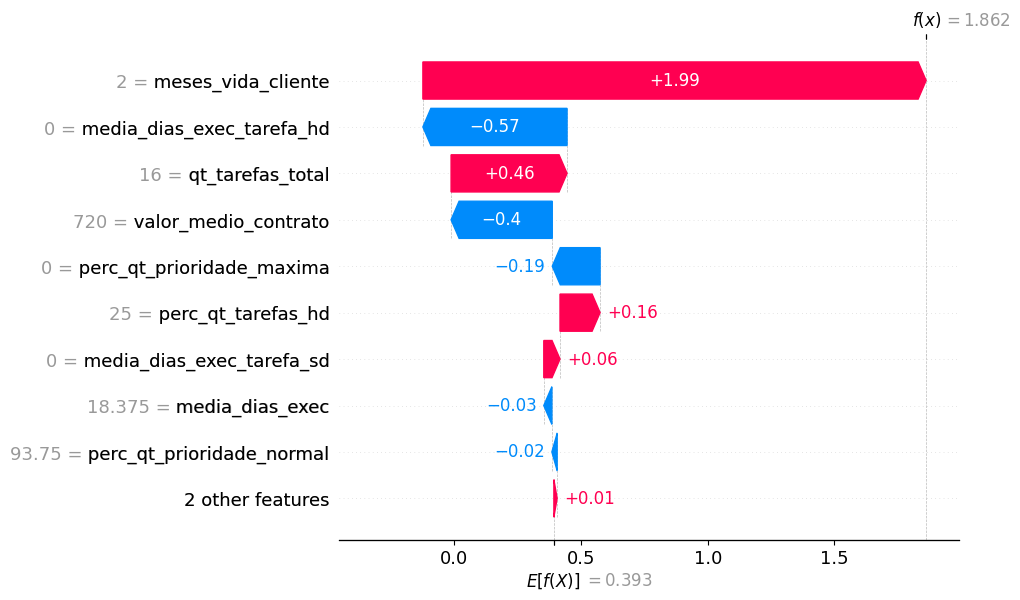

In [68]:
# Inicializa o renderizador de JavaScript para exibir os gráficos no Notebook
shap.initjs()

explainer = shap.TreeExplainer(modelo_xgb)

X_test_shap = pd.DataFrame(X_test, columns=X_test.columns)
shap_values = explainer(X_test_shap)

print("--- VISÃO GLOBAL DE IMPACTO DAS FEATURES ---")
shap.summary_plot(shap_values, X_test_shap)

# Pega o primeiro cliente do set de teste (índice 0) para auditar o porquê do score dele
print("\n--- AUDITORIA INDIVIDUAL: POR QUE ESTE CLIENTE RECEBEU ESSE SCORE? ---")
shap.plots.waterfall(shap_values[0])

## Tuning

In [69]:
param_grid_xgb = {
    'max_depth':        [3 , 5 , 7], 
    'learning_rate':    [0.1 , 0.01 , 0.001], 
    'subsample':        [0.5 , 0.7 , 1],
    'n_estimators':     [50, 100, 150],
    'subsample':        [0.5 , 0.6, 0.7, 0.8, 0.9, 1],
    'colsample_bytree': [0.5 , 0.6, 0.7, 0.8, 0.9, 1]
    # 'early_stopping_rounds': [10, 20, 30]
} 

In [70]:
modelo_rs_xgb = RandomizedSearchCV(
    estimator=modelo_xgb,
    param_distributions=param_grid_xgb,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42
)

modelo_rs_xgb.fit(X_train_scaled, y_train)

print ( "Melhor conjunto de hiperparâmetros: ", modelo_rs_xgb.best_params_) 
print ( "Melhor pontuação: ", modelo_rs_xgb.best_score_)

Melhor conjunto de hiperparâmetros:  {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 1}
Melhor pontuação:  0.9140084272955589


In [71]:
y_pred_rs_xgb  = modelo_rs_xgb.predict(X_test_scaled)
y_probs_rs_xgb = modelo_rs_xgb.predict_proba(X_test_scaled)[:, 1]

### Métricas

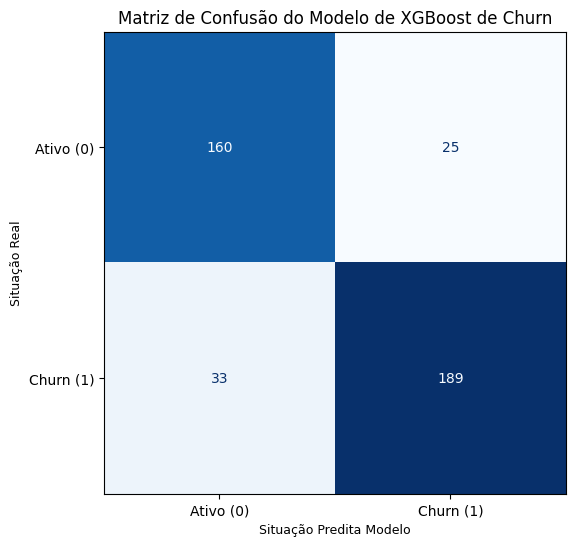

In [72]:
cm_xgb = confusion_matrix(y_test, y_pred_rs_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=['Ativo (0)', 'Churn (1)'])
fig, ax = plt.subplots(figsize=(6, 6))
ax.grid(False)

disp.plot(cmap='Blues', values_format='d', colorbar=False, ax=ax) # 'd' força a exibição como número inteiro

plt.title('Matriz de Confusão do Modelo de XGBoost de Churn')
plt.ylabel('Situação Real', fontsize=9)
plt.xlabel('Situação Predita Modelo', fontsize=9)
plt.show()

ROC AUC Score: 0.94


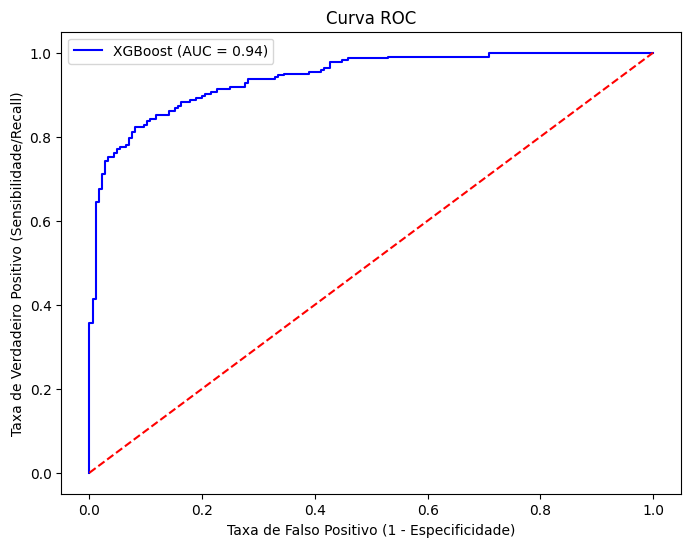

In [73]:
# ROC AUC Score
auc = roc_auc_score(y_test, y_probs_rs_xgb)
print(f"ROC AUC Score: {auc:.2f}")

# Plotando a Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_probs_rs_xgb)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'XGBoost (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('Taxa de Falso Positivo (1 - Especificidade)')
plt.ylabel('Taxa de Verdadeiro Positivo (Sensibilidade/Recall)')
plt.title('Curva ROC')
plt.legend()
plt.show()

In [74]:
# Relatório de Classificação (Precision, Recall, F1-Score)
print("--- RELATÓRIO DE CLASSIFICAÇÃO ---")
print(classification_report(y_test, y_pred_rs_xgb))

--- RELATÓRIO DE CLASSIFICAÇÃO ---
              precision    recall  f1-score   support

           0       0.83      0.86      0.85       185
           1       0.88      0.85      0.87       222

    accuracy                           0.86       407
   macro avg       0.86      0.86      0.86       407
weighted avg       0.86      0.86      0.86       407



In [75]:
recall_rs_xgb   = recall_score(y_test, y_pred_rs_xgb)
precisao_rs_xgb = precision_score(y_test, y_pred_rs_xgb)
acuracia_rs_xgb = accuracy_score(y_test, y_pred_rs_xgb)
f1_score_rs_xgb = f1_score(y_test, y_pred_rs_xgb)
roc_auc_rs_xgb  = roc_auc_score(y_test, y_probs_rs_xgb)

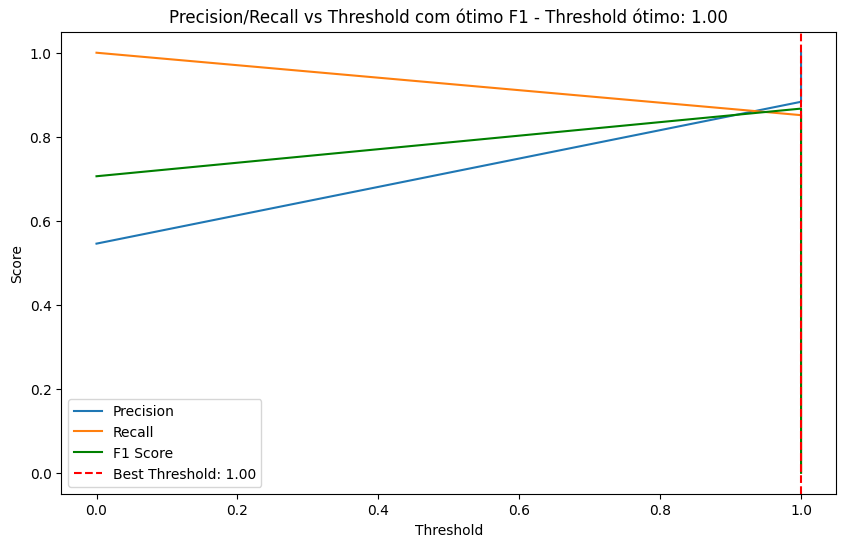

In [76]:
best_threshold_rs_xgb = plot_precision_recall_curve(y_test, y_pred_rs_xgb)

## CalibratedClassifierCV

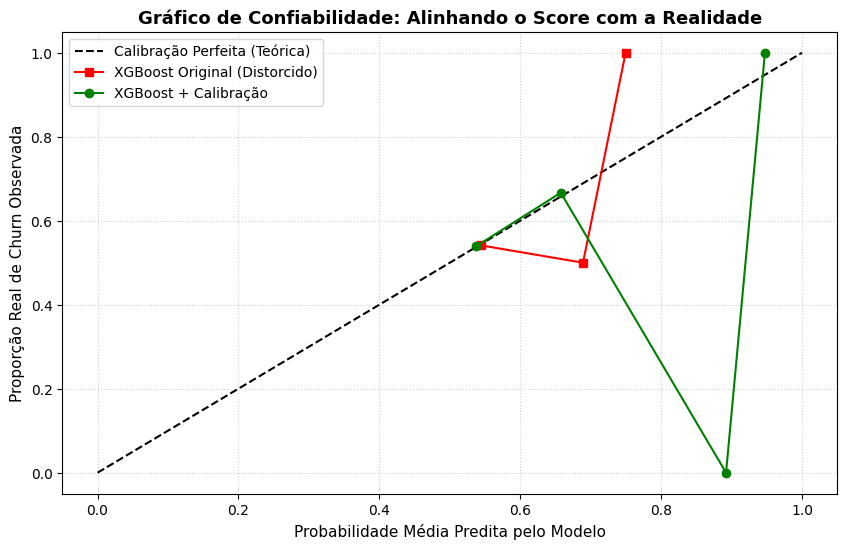

In [77]:
# Instanciar o calibrador usando o modelo XGBoost já configurado
modelo_xgb_calibrado = CalibratedClassifierCV(
    estimator=modelo_xgb,
    method='sigmoid',
    cv='prefit'
)

modelo_xgb_calibrado.fit(X_calib_scaled, y_calib)

# Diagnóstico visual: compara probabilidades no próprio conjunto de calibração
prob_originais  = modelo_xgb.predict_proba(X_calib_scaled)[:, 1]
prob_calibradas = modelo_xgb_calibrado.predict_proba(X_calib_scaled)[:, 1]

sub_y_orig,  sub_x_orig  = calibration_curve(y_calib, prob_originais,  n_bins=10)
sub_y_calib, sub_x_calib = calibration_curve(y_calib, prob_calibradas, n_bins=10)

plt.figure(figsize=(10, 6))
plt.plot([0, 1], [0, 1], "k--", label="Calibração Perfeita (Teórica)")
plt.plot(sub_x_orig,  sub_y_orig,  "s-", color="red",   label="XGBoost Original (Distorcido)")
plt.plot(sub_x_calib, sub_y_calib, "o-", color="green", label="XGBoost + Calibração")
plt.xlabel("Probabilidade Média Predita pelo Modelo", fontsize=11)
plt.ylabel("Proporção Real de Churn Observada", fontsize=11)
plt.title("Gráfico de Confiabilidade: Alinhando o Score com a Realidade", fontsize=13, fontweight='bold')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc="upper left")
plt.show()

# Avaliação final — X_test nunca tocado durante treino nem calibração
y_pred_xgb_calibrado  = modelo_xgb_calibrado.predict(X_test_scaled)
y_probs_xgb_calibrado = modelo_xgb_calibrado.predict_proba(X_test_scaled)[:, 1]

In [78]:
y_pred_xgb_calibrado  = modelo_xgb_calibrado.predict(X_test)
y_probs_xgb_calibrado = modelo_xgb_calibrado.predict_proba(X_test)[:, 1]

### Métricas

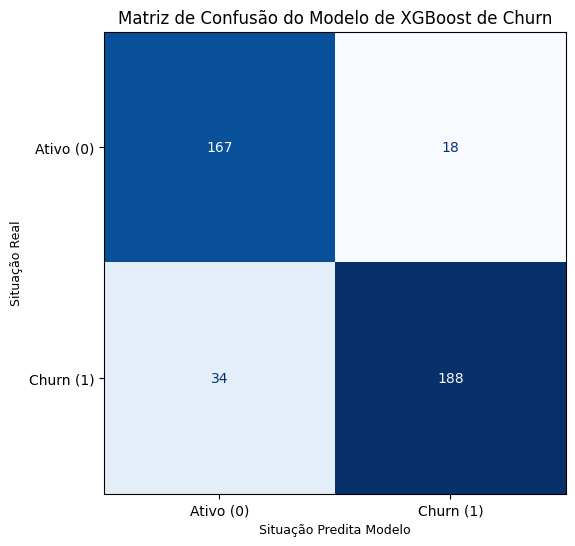

In [79]:
cm_xgb_calibrado = confusion_matrix(y_test, y_pred_xgb_calibrado)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_xgb_calibrado, display_labels=['Ativo (0)', 'Churn (1)'])
fig, ax = plt.subplots(figsize=(6, 6))
ax.grid(False)

disp.plot(cmap='Blues', values_format='d', colorbar=False, ax=ax) # 'd' força a exibição como número inteiro

plt.title('Matriz de Confusão do Modelo de XGBoost de Churn')
plt.ylabel('Situação Real', fontsize=9)
plt.xlabel('Situação Predita Modelo', fontsize=9)
plt.show()

ROC AUC Score: 0.94


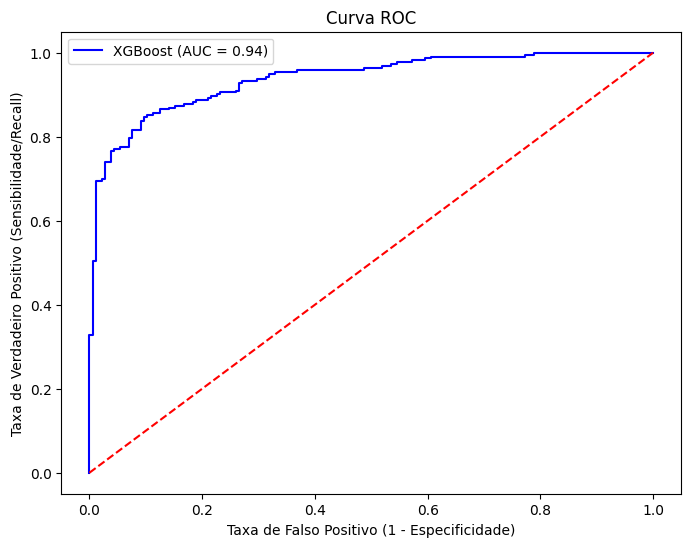

In [80]:
# ROC AUC Score
auc = roc_auc_score(y_test, y_probs_xgb_calibrado)
print(f"ROC AUC Score: {auc:.2f}")

# Plotando a Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_probs_xgb_calibrado)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'XGBoost (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('Taxa de Falso Positivo (1 - Especificidade)')
plt.ylabel('Taxa de Verdadeiro Positivo (Sensibilidade/Recall)')
plt.title('Curva ROC')
plt.legend()
plt.show()

In [81]:
# Relatório de Classificação (Precision, Recall, F1-Score)
print("--- RELATÓRIO DE CLASSIFICAÇÃO ---")
print(classification_report(y_test, y_pred_xgb_calibrado))

--- RELATÓRIO DE CLASSIFICAÇÃO ---
              precision    recall  f1-score   support

           0       0.83      0.90      0.87       185
           1       0.91      0.85      0.88       222

    accuracy                           0.87       407
   macro avg       0.87      0.87      0.87       407
weighted avg       0.88      0.87      0.87       407



In [82]:
recall_xgb_calibrado   = recall_score(y_test, y_pred_xgb_calibrado)
precisao_xgb_calibrado = precision_score(y_test, y_pred_xgb_calibrado)
acuracia_xgb_calibrado = accuracy_score(y_test, y_pred_xgb_calibrado)
f1_score_xgb_calibrado = f1_score(y_test, y_pred_xgb_calibrado)
roc_auc_xgb_calibrado  = roc_auc_score(y_test, y_probs_xgb_calibrado)

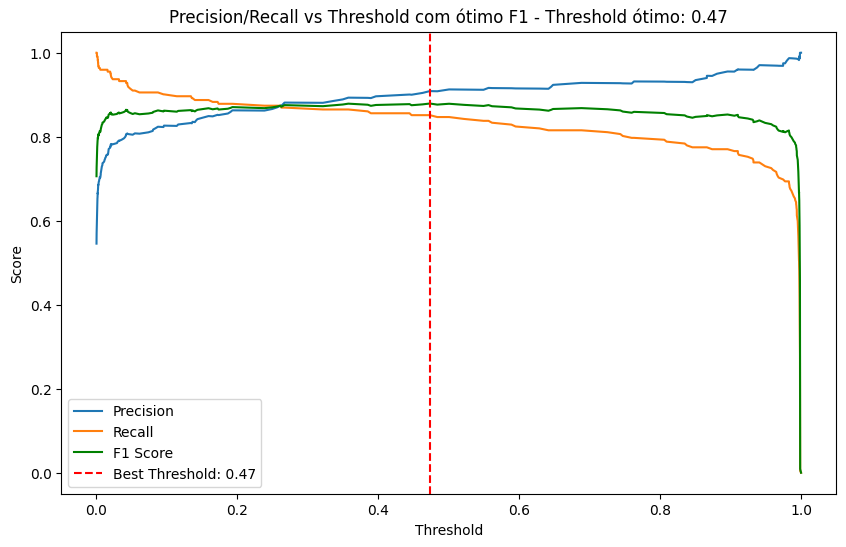

In [83]:
best_threshold_xgb_calibrado = plot_precision_recall_curve(y_test, y_probs_xgb_calibrado)

### Salva Modelo Calibrado

In [84]:
joblib.dump(modelo_xgb_calibrado, 'src/modelo_xgb_calibrado.pkl')

['src/modelo_xgb_calibrado.pkl']

# Compara Métricas

In [85]:
# Estruturando os dados
dados_metricas = {
    "Modelo": [
        "Regressão Logística",
        "Regressão Logística Limpa",
        "Random Forest",
        "XGBoost",
        "XGBoost Tuning",
        "XGBoost Calibrado"
    ]
    * 5,
    "Métrica": (
        ["Precisão"]    * 6
        + ["Recall"]    * 6
        + ["Acurácia"]  * 6
        + ["F1-Score"]  * 6
        + ["ROC AUC"]   * 6
    ),
    "Valor": [
        precisao_reglog,
        precisao_reglog_limpo,
        precisao_rf,
        precisao_xgb,
        precisao_rs_xgb,
        precisao_xgb_calibrado,
        recall_reglog,
        recall_reglog_limpo,
        recall_rf,
        recall_xgb,
        recall_rs_xgb,
        recall_xgb_calibrado,
        acuracia_reglog,
        acuracia_reglog_limpo,
        acuracia_rf,
        acuracia_xgb,
        acuracia_rs_xgb,
        acuracia_xgb_calibrado,
        f1_score_reglog,
        f1_score_reglog_limpo,
        f1_score_rf,
        f1_score_xgb,
        f1_score_rs_xgb,
        f1_score_xgb_calibrado,
        roc_auc_reglog,
        roc_auc_reglog_limpo,
        roc_auc_rf,
        roc_auc_xgb,
        roc_auc_rs_xgb,
        roc_auc_xgb_calibrado
    ]
}

df_metrics = pd.DataFrame(dados_metricas)
df_metrics

,Modelo,Métrica,Valor
0,Regressão Logística,Precisão,0.862069
1,Regressão Logística Limpa,Precisão,0.840183
2,Random Forest,Precisão,0.910448
3,XGBoost,Precisão,0.892523
4,XGBoost Tuning,Precisão,0.883178
5,XGBoost Calibrado,Precisão,0.912621
6,Regressão Logística,Recall,0.788288
7,Regressão Logística Limpa,Recall,0.828829
8,Random Forest,Recall,0.824324
9,XGBoost,Recall,0.860360


## Plot

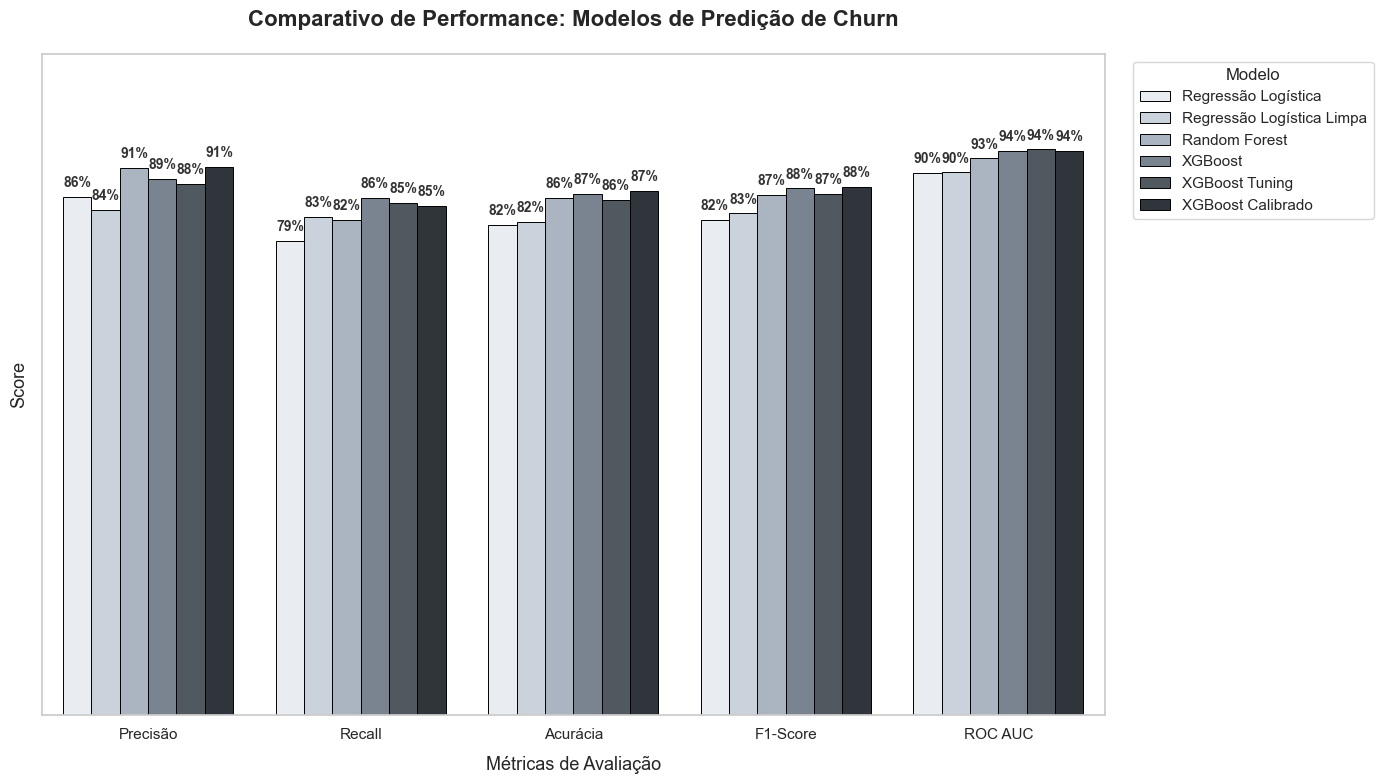

In [86]:
# Configurando o visual do gráfico
plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid")

# Paleta de cores sênior e profissional
cores = ["#e8edf2", "#c7d2de", "#a6b5c5", "#768494", "#4d5863", '#2d353d']

# Criando o gráfico de barras agrupadas por Métrica
ax = sns.barplot(
    data=df_metrics,
    x="Métrica",
    y="Valor",
    hue="Modelo",
    palette=cores,
    edgecolor="black",
    linewidth=0.7,
)

# Perfumaria Executiva (Títulos e Legendas)
plt.title(
    "Comparativo de Performance: Modelos de Predição de Churn",
    fontsize=16,
    fontweight="bold",
    pad=20,
)
plt.xlabel("Métricas de Avaliação", fontsize=13, labelpad=10)
plt.ylabel("Score", fontsize=13, labelpad=10)
plt.ylim(0, 1.1)  # Dá um respiro no topo para os rótulos de texto
plt.yticks([], [])

# Move a legenda para fora/canto para não atrapalhar as barras
plt.legend(
    title="Modelo",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=11,
    title_fontsize=12,
)

# Adicionando os valores exatos em cima de cada barra automaticamente
for p in ax.patches:
    if (
        p.get_height() > 0
    ):  # Garante que só vai plotar se a barra tiver altura
        ax.annotate(
            f"{p.get_height() * 100:.0f}%",  # Mostra em formato de porcentagem limpa (ex: 95%)
            (p.get_x() + p.get_width() / 2.0, p.get_height()),
            ha="center",
            va="center",
            xytext=(0, 10),
            textcoords="offset points",
            fontsize=10,
            fontweight="bold",
            color="#333333",
        )

plt.tight_layout()
plt.show()

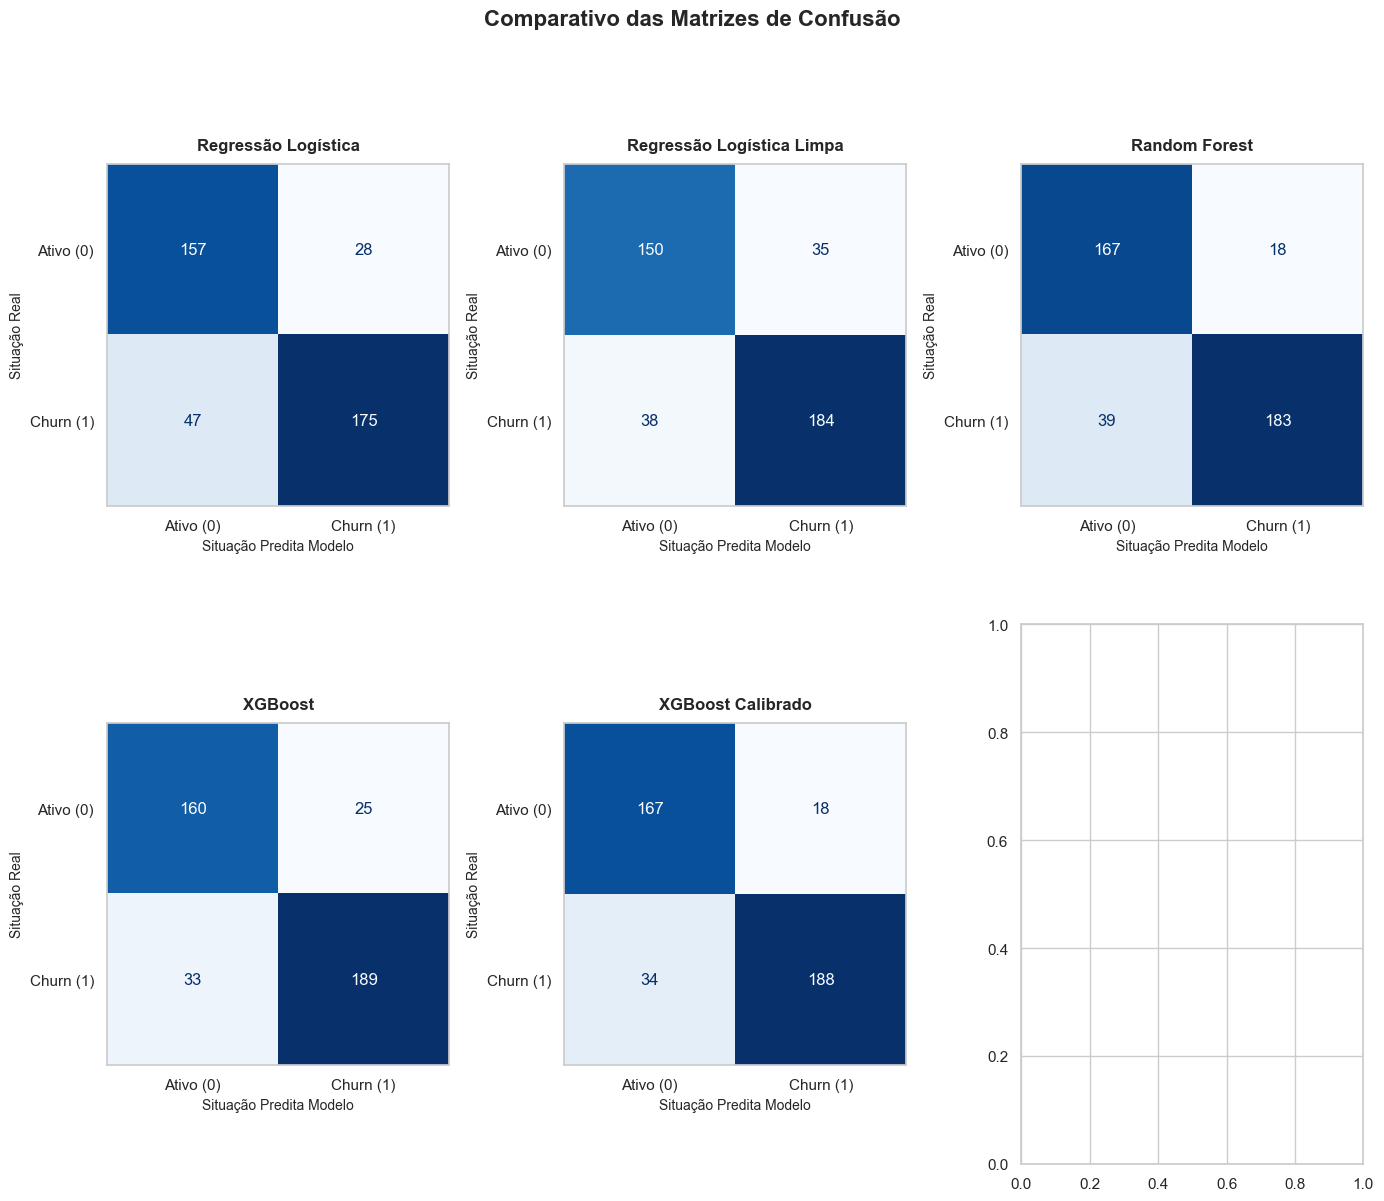

In [87]:
# Matrizes de confusão
fig, axes = plt.subplots(2, 3, figsize=(14, 12))
fig.suptitle('Comparativo das Matrizes de Confusão', fontsize=16, fontweight='bold', y=1)

# Lista de configurações para iterar no loop
modelos = [
    {"cm": cm_reglog,        "title": "Regressão Logística",        "ax": axes[0, 0]},
    {"cm": cm_reglog_limpo,  "title": "Regressão Logística Limpa",  "ax": axes[0, 1]},
    {"cm": cm_rf,            "title": "Random Forest",              "ax": axes[0, 2]},
    {"cm": cm_xgb,           "title": "XGBoost",                    "ax": axes[1, 0]},
    {"cm": cm_xgb_calibrado, "title": "XGBoost Calibrado",          "ax": axes[1, 1]}
]

# Plotar cada matriz no seu respectivo 'ax'
for mod in modelos:
    mod["ax"].grid(False)  # Remove linhas de grade que desalinhame a matriz
    disp = ConfusionMatrixDisplay(
        confusion_matrix=mod["cm"],
        display_labels=['Ativo (0)',
                        'Churn (1)']
                        )

    # O segredo está em passar o 'ax' correto para o plot
    disp.plot(cmap='Blues', values_format='d', colorbar=False, ax=mod["ax"])

    # Customizações por sub-plot
    mod["ax"].set_title(mod["title"], fontsize=12, fontweight='bold', pad=10)
    mod["ax"].set_ylabel('Situação Real', fontsize=10)
    mod["ax"].set_xlabel('Situação Predita Modelo', fontsize=10)

# Ajusta o espaçamento para não sobrepor os textos
plt.tight_layout()
plt.show()

## Análise de Cutoff

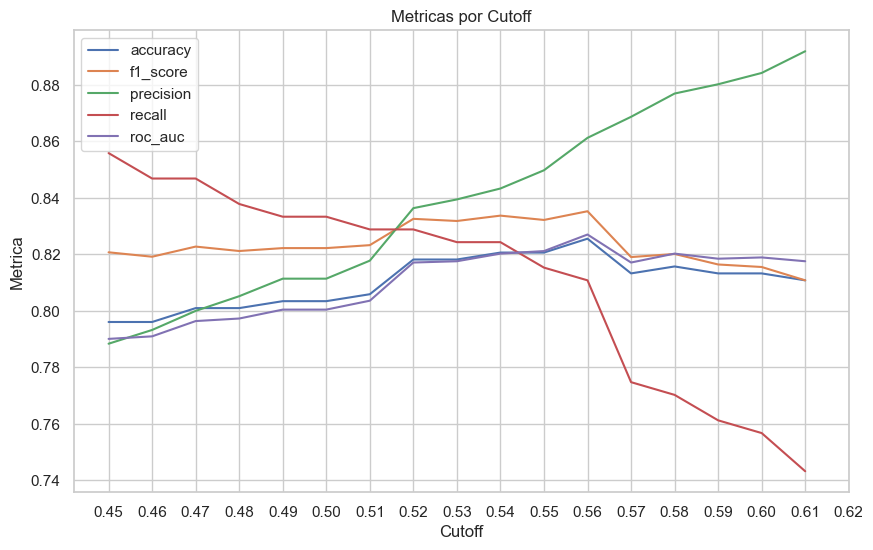

In [88]:
analise_cutoff(y_test, y_probs_reglog, min_cutoff=0.45, max_cutoff=0.62, passo=0.01)

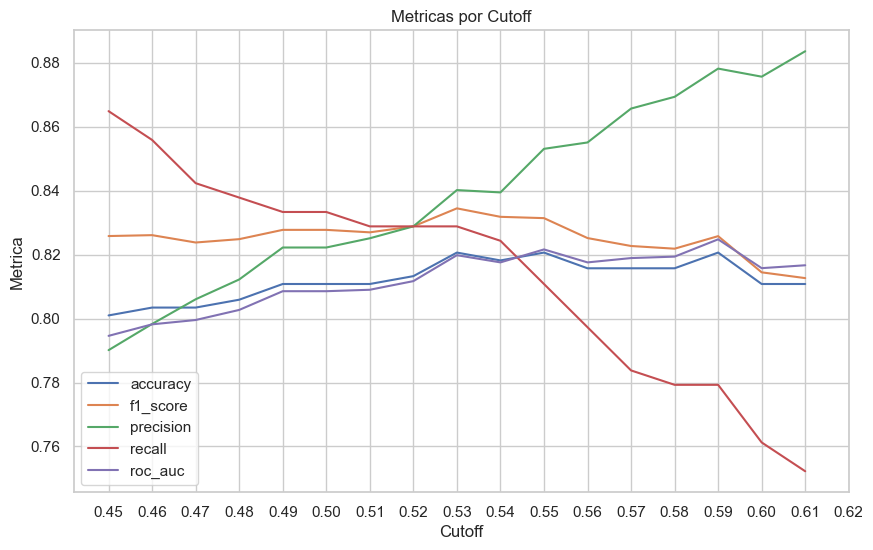

In [89]:
analise_cutoff(y_test, y_probs_reglog_limpo, min_cutoff=0.45, max_cutoff=0.62, passo=0.01)

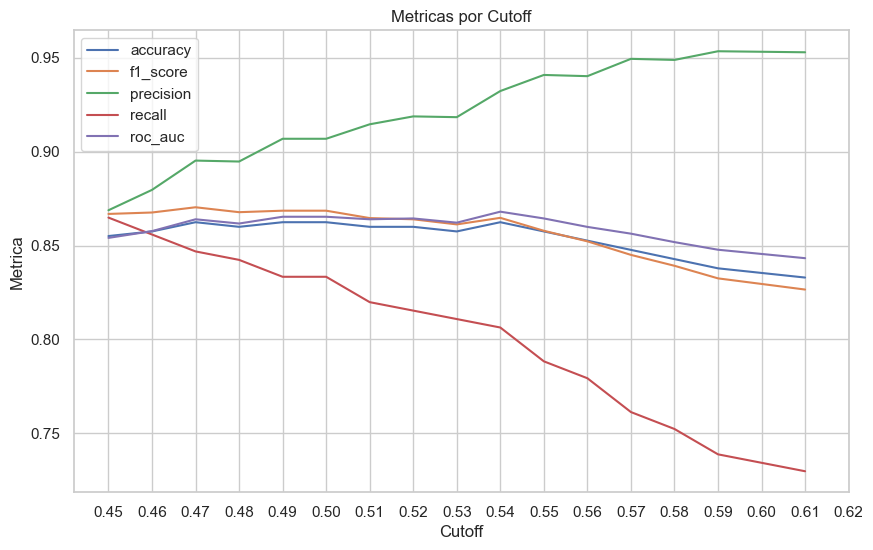

In [90]:
analise_cutoff(y_test, y_probs_rf, min_cutoff=0.45, max_cutoff=0.62, passo=0.01)

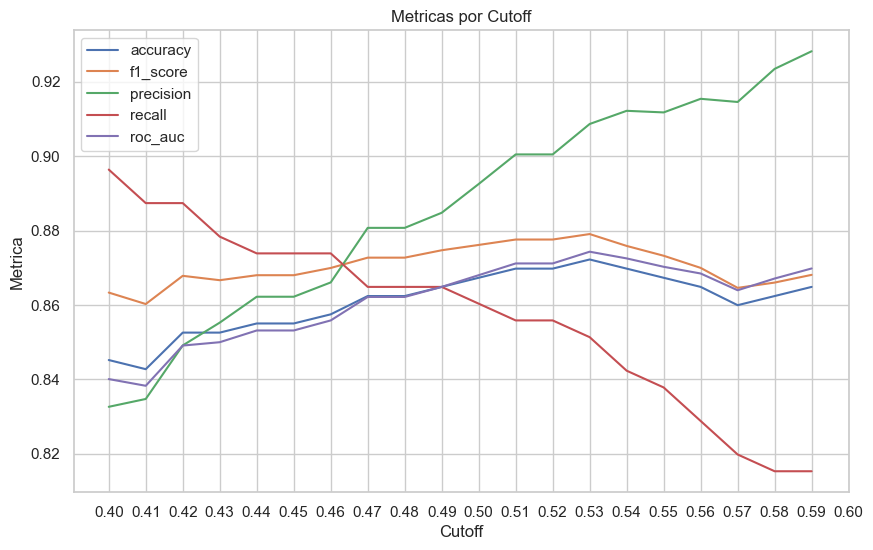

In [91]:
analise_cutoff(y_test, y_probs_xgb, min_cutoff=0.4, max_cutoff=0.6, passo=0.01)

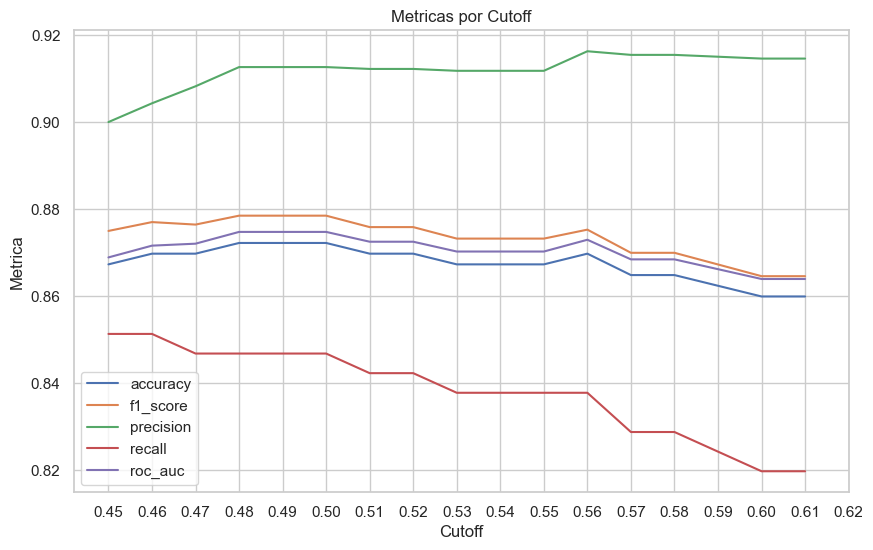

In [92]:
analise_cutoff(y_test, y_probs_xgb_calibrado, min_cutoff=0.45, max_cutoff=0.62, passo=0.01)